# EDA part 3

In [4]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11


In [5]:
spark = (
    SparkSession.builder.appName("EDAs")
    .config("spark.driver.memory", "16g")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.parquet.filterPushdown", "true")
    .getOrCreate()
)


In [6]:
spark

In [7]:
DATA_PATH = "D:/HSE/Diplom/models/exported/train_raw.parquet"
COLUMNS_PATH = "D:/HSE/Diplom/models/exported/columns.json"
FEATURE_IMPORTANCE_PATH = next(
    (p for p in [
        "models/charts/feature_importance_xgboost_native.csv",
        "../models/charts/feature_importance_xgboost_native.csv",
    ] if Path(p).exists()),
    "models/charts/feature_importance_xgboost_native.csv",
)

ALT_RATE_COL = "gs10_monthly"
SPREAD_COL = "rate_spread_to_10y"
LOGIT_SPREAD_COL = "logit_rate_spread_to_10y"

with open(COLUMNS_PATH, "r") as fh:
    columns_meta = json.load(fh)

TARGET_COL = columns_meta.get("target_col", "smm_target")

required_cols = [
    "smm_target",
    "gs10_monthly",
    "rate_spread_to_10y",
    "logit_rate_spread_to_10y",
    "current_interest_rate",
    "fico",
    "loan_age",
    "reporting_date",
    "seasoning_bucket",
    "fico_bucket",
    "is_refi",
    "orig_loan_term",
    "is_high_bal",
    "remaining_months_to_mat",
    "ph_delinq_count",
    "upb_fraction",
    "orig_upb",
    "first_time_buyer",
    "age_sq",
    "is_judicial_state",
    "spread_pos",
    "occupancy_status",
    "loan_purpose",
    "property_type",
    "pct_term_elapsed",
    "month_of_year",
    "dti",
]


In [8]:
raw = spark.read.parquet(DATA_PATH)
available_cols = [c for c in required_cols if c in raw.columns]

missing_cols = sorted(set(required_cols) - set(available_cols))
if missing_cols:
    print("Missing columns:", missing_cols)

df = (
    raw.select(*available_cols)
    .filter(F.col(TARGET_COL).isNotNull())
    .withColumn(TARGET_COL, F.col(TARGET_COL).cast("double"))
    .cache()
)

df.select(F.count("*").alias("rows"), F.avg(TARGET_COL).alias("mean_smm")).show()


+--------+--------------------+
|    rows|            mean_smm|
+--------+--------------------+
|74195130|0.013296519596367039|
+--------+--------------------+



In [9]:
def make_bucket_col(df, col, n_bins=16, rel_error=None):
    bounds = (
        df.filter(F.col(col).isNotNull())
        .agg(F.min(col).alias("x_min"), F.max(col).alias("x_max"))
        .first()
    )

    if bounds is None or bounds["x_min"] is None or bounds["x_max"] is None:
        return F.lit(None).cast("int"), []

    x_min = float(bounds["x_min"])
    x_max = float(bounds["x_max"])

    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return F.lit(0).cast("int"), [x_min, x_max]

    width = (x_max - x_min) / n_bins
    raw_bucket = F.floor((F.col(col) - F.lit(x_min)) / F.lit(width))
    bucket = F.least(F.greatest(raw_bucket, F.lit(0)), F.lit(n_bins - 1))
    cuts = [x_min + width * i for i in range(n_bins + 1)]

    return bucket.cast("int"), cuts


def aggregate_rate_curve(df, feature, n_bins=16, min_n=1000):
    bucket_col, cuts = make_bucket_col(df, feature, n_bins=n_bins)

    agg = (
        df.filter(F.col(feature).isNotNull())
        .withColumn("bucket", bucket_col)
        .groupBy("bucket")
        .agg(
            F.count("*").alias("n"),
            F.sum(TARGET_COL).alias("n_prepaid"),
            F.avg(TARGET_COL).alias("smm"),
            F.avg(feature).alias("x_mean"),
            F.min(feature).alias("x_min"),
            F.max(feature).alias("x_max"),
        )
        .filter(F.col("n") >= min_n)
        .orderBy("bucket")
        .toPandas()
    )

    if agg.empty:
        return agg, cuts

    z = 1.96
    agg["smm_pct"] = 100 * agg["smm"]
    agg["cpr_pct"] = 100 * (1 - (1 - agg["smm"]) ** 12)
    agg["ci_pct"] = 100 * z * np.sqrt(agg["smm"] * (1 - agg["smm"]) / agg["n"].clip(lower=1))
    if len(cuts) == n_bins + 1:
        edges = pd.DataFrame({
            "bucket": range(n_bins),
            "x_left": cuts[:-1],
            "x_right": cuts[1:],
        })
        agg = agg.merge(edges, on="bucket", how="left")
        agg["bucket_label"] = agg.apply(lambda r: f"{r['x_right']:.2f}", axis=1)
    else:
        agg["bucket_label"] = agg.apply(lambda r: f"{r['x_max']:.2f}", axis=1)
    return agg, cuts


def plot_rate_curve(agg, x_label, title, color="#1f77b4", show_volume=True):
    if agg.empty:
        print("No aggregated data to plot.")
        return

    fig, ax = plt.subplots(figsize=(10.5, 5.6))
    x_pos = agg["x_right"].to_numpy() if "x_right" in agg.columns else np.arange(len(agg))
    tick_labels = agg["bucket_label"].tolist() if "bucket_label" in agg.columns else [f"{x:.2f}" for x in agg["x_mean"]]
    if "x_left" in agg.columns and "x_right" in agg.columns:
        widths = (agg["x_right"] - agg["x_left"]).replace(0, np.nan)
        bar_width = float(widths.median()) * 0.78
    else:
        bar_width = 0.78

    ax.errorbar(
        x_pos,
        agg["smm_pct"],
        yerr=agg["ci_pct"],
        fmt="o-",
        linewidth=2.2,
        markersize=5,
        capsize=3,
        color=color,
        label="Prepayment probability",
    )
    ax.set_xlabel(x_label)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(tick_labels, rotation=35, ha="right")
    ax.set_ylabel("Next-month prepayment probability, %")
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f%%"))
    ax.grid(True, alpha=0.25)

    if show_volume:
        ax2 = ax.twinx()
        ax2.bar(x_pos, agg["n"], width=-bar_width, align="edge", alpha=0.10, color="grey")
        ax2.set_ylabel("Number of loan-months")
        ax2.grid(False)

    fig.tight_layout()
    plt.show()


## GS10

In [10]:
gs10_curve, gs10_cuts = aggregate_rate_curve(df, ALT_RATE_COL, n_bins=15, min_n=1000)
display(gs10_curve[["bucket", "bucket_label", "n", "n_prepaid", "smm_pct", "cpr_pct"]])


,bucket,bucket_label,n,n_prepaid,smm_pct,cpr_pct
0,0,0.90,4114063,119787.0,2.911647,29.853566
1,1,1.18,761579,21600.0,2.836213,29.196746
2,2,1.46,1290263,36455.0,2.825393,29.102076
3,3,1.73,7966984,166905.0,2.094958,22.435915
4,4,2.01,10167587,163778.0,1.610785,17.705667
5,5,2.29,13860010,158713.0,1.145115,12.908125
6,6,2.57,16326288,159839.0,0.979028,11.135930
7,7,2.85,4717093,34756.0,0.736810,8.492066
8,8,3.13,6038501,61855.0,1.024344,11.622709
9,9,3.41,881946,7663.0,0.868874,9.942380


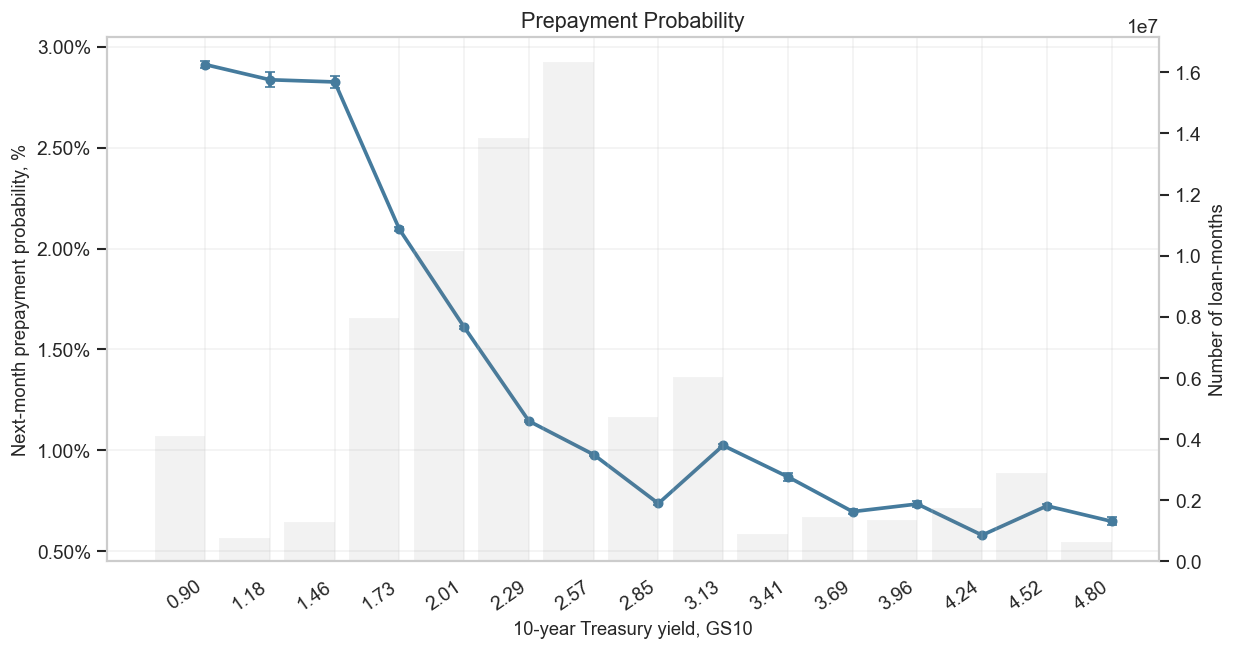

In [16]:
plot_rate_curve(
    gs10_curve,
    x_label="10-year Treasury yield, GS10",
    title="Prepayment Probability",
    color="#457b9d",
)


## Spread to GS10

In [14]:
spread_curve, spread_cuts = aggregate_rate_curve(df, SPREAD_COL, n_bins=18, min_n=1000)
display(spread_curve[["bucket", "bucket_label", "n", "n_prepaid", "smm_pct", "cpr_pct"]])


,bucket,bucket_label,n,n_prepaid,smm_pct,cpr_pct
0,1,-1.85,3063,24.0,0.783546,9.007743
1,2,-1.37,63980,521.0,0.814317,9.345814
2,3,-0.90,426396,4225.0,0.990863,11.263294
3,4,-0.42,934863,8526.0,0.912005,10.411457
4,5,0.05,1931784,13365.0,0.691848,7.993433
5,6,0.53,3180637,21143.0,0.664741,7.691618
6,7,1.00,4176025,29362.0,0.703109,8.118554
7,8,1.48,7585986,62804.0,0.827895,9.494624
8,9,1.95,12831850,118647.0,0.924629,10.548322
9,10,2.43,17737433,205348.0,1.157710,13.041189


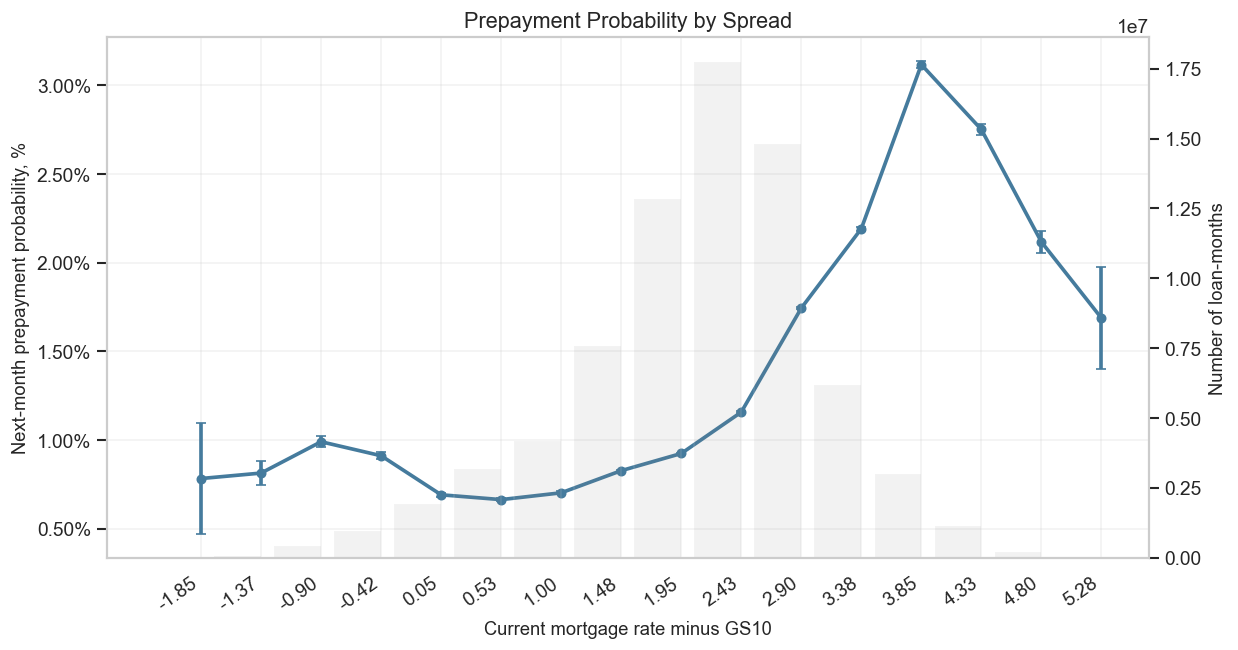

In [15]:
plot_rate_curve(
    spread_curve,
    x_label="Current mortgage rate minus GS10",
    title="Prepayment Probability by Spread",
    color="#457b9d",
)

## Sigma(spread)

In [17]:
logit_curve, logit_cuts = aggregate_rate_curve(df, LOGIT_SPREAD_COL, n_bins=18, min_n=1000)
display(logit_curve[["bucket", "bucket_label", "n", "n_prepaid", "smm_pct", "cpr_pct"]])


,bucket,bucket_label,n,n_prepaid,smm_pct,cpr_pct
0,1,0.16,10977,72.0,0.655917,7.593171
1,2,0.21,67023,549.0,0.819122,9.398499
2,3,0.27,249272,2443.0,0.980054,11.146973
3,4,0.32,417710,4257.0,1.019128,11.566808
4,5,0.37,442174,3959.0,0.895349,10.230575
5,6,0.42,533257,4426.0,0.829994,9.517606
6,7,0.47,900470,6179.0,0.686197,7.930594
7,8,0.53,986311,6370.0,0.645841,7.480639
8,9,0.58,1298965,8114.0,0.624651,7.243577
9,10,0.63,1688388,11829.0,0.700609,8.090794


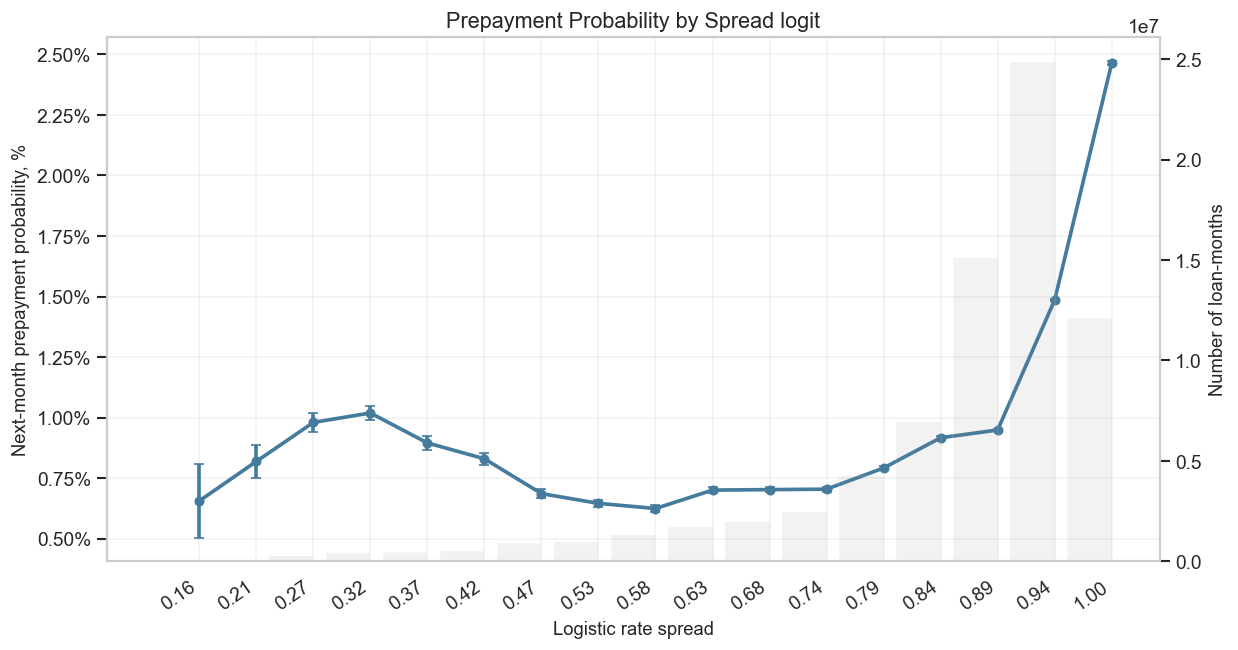

In [18]:
plot_rate_curve(
    logit_curve,
    x_label="Logistic rate spread",
    title="Prepayment Probability by Spread logit",
    color="#457b9d",
)


## SMM vs alternative rate

In [19]:
monthly = (
    df.filter(F.col("reporting_date").isNotNull() & F.col(ALT_RATE_COL).isNotNull())
    .groupBy("reporting_date")
    .agg(
        F.count("*").alias("n"),
        F.avg(TARGET_COL).alias("smm"),
        F.avg(ALT_RATE_COL).alias("gs10"),
        F.avg(SPREAD_COL).alias("spread"),
    )
    .orderBy("reporting_date")
    .toPandas()
)

monthly["reporting_date"] = pd.to_datetime(monthly["reporting_date"])
monthly["smm_pct"] = monthly["smm"] * 100
display(monthly.head())


,reporting_date,n,smm,gs10,spread,smm_pct
0,2014-01-01,73415,0.001117,2.86,1.522151,0.111694
1,2014-02-01,160006,0.001819,2.71,1.723545,0.181868
2,2014-03-01,235010,0.002340,2.72,1.729321,0.234033
3,2014-04-01,327479,0.002956,2.71,1.731510,0.295591
4,2014-05-01,420671,0.004310,2.56,1.878551,0.430978


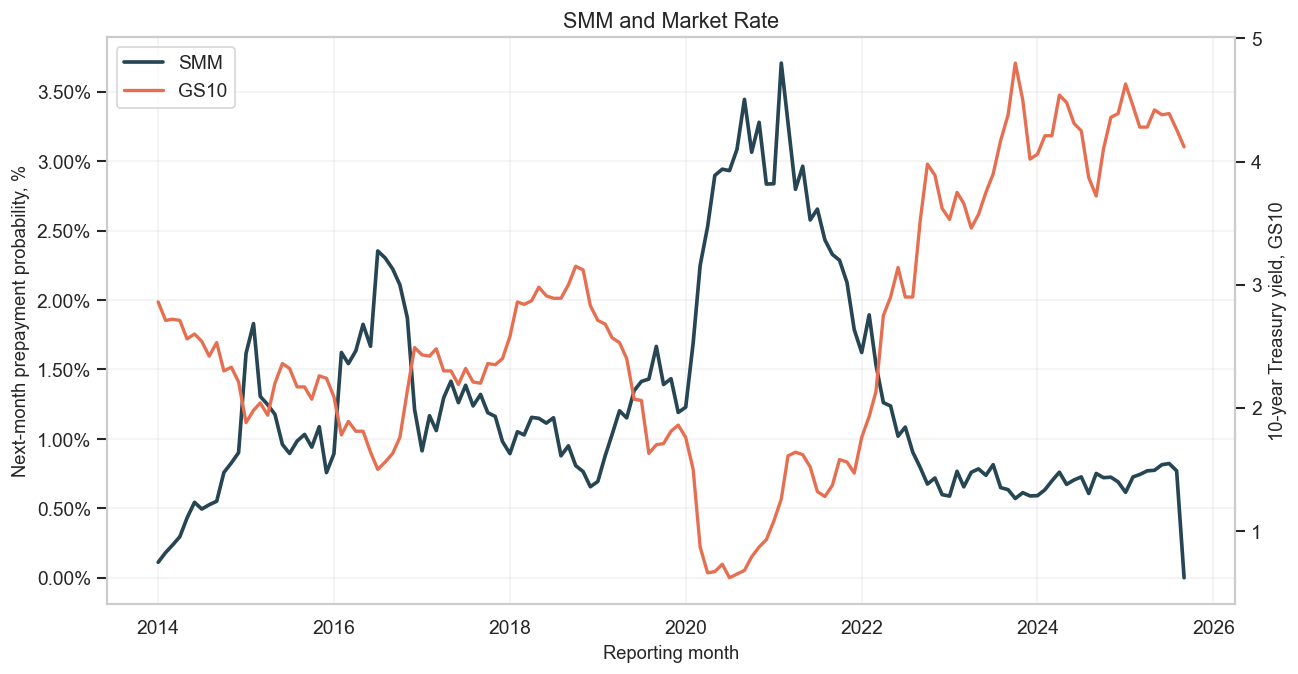

In [20]:
fig, ax = plt.subplots(figsize=(11, 5.8))

ax.plot(monthly["reporting_date"], monthly["smm_pct"], color="#264653", linewidth=2.2, label="SMM")
ax.set_xlabel("Reporting month")
ax.set_ylabel("Next-month prepayment probability, %")
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f%%"))
ax.grid(True, alpha=0.25)

ax2 = ax.twinx()
ax2.plot(monthly["reporting_date"], monthly["gs10"], color="#e76f51", linewidth=2.0, label="GS10")
ax2.set_ylabel("10-year Treasury yield, GS10")
ax2.grid(False)

lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

ax.set_title("SMM and Market Rate")
fig.tight_layout()
plt.show()


## Season vs prepaym

In [21]:
def aggregate_curve_by_group(df, feature, group_col, groups=None, n_bins=10, min_n=500):
    if group_col not in df.columns:
        return pd.DataFrame()

    bucket_col, _ = make_bucket_col(df, feature, n_bins=n_bins)
    base = df.filter(F.col(feature).isNotNull() & F.col(group_col).isNotNull()).withColumn("bucket", bucket_col)

    if groups is not None:
        base = base.filter(F.col(group_col).isin(groups))

    return (
        base.groupBy(group_col, "bucket")
        .agg(
            F.count("*").alias("n"),
            F.avg(TARGET_COL).alias("smm"),
            F.avg(feature).alias("x_mean"),
        )
        .filter(F.col("n") >= min_n)
        .orderBy(group_col, "bucket")
        .toPandas()
    )


seasoning_order = ["0-12m", "13-36m", "37-60m", "61-120m", "120m+"]
seasoning_curve = aggregate_curve_by_group(
    df,
    LOGIT_SPREAD_COL,
    "seasoning_bucket",
    groups=seasoning_order,
    n_bins=10,
    min_n=500,
)
seasoning_curve["smm_pct"] = seasoning_curve["smm"] * 100
display(seasoning_curve.head())


,seasoning_bucket,bucket,n,smm,x_mean,smm_pct
0,0-12m,4,1198,0.002504,0.497929,0.250417
1,0-12m,5,15004,0.001133,0.592445,0.113303
2,0-12m,6,346916,0.002473,0.685329,0.247322
3,0-12m,7,1420163,0.005391,0.766455,0.539093
4,0-12m,8,6558919,0.006347,0.873745,0.634678


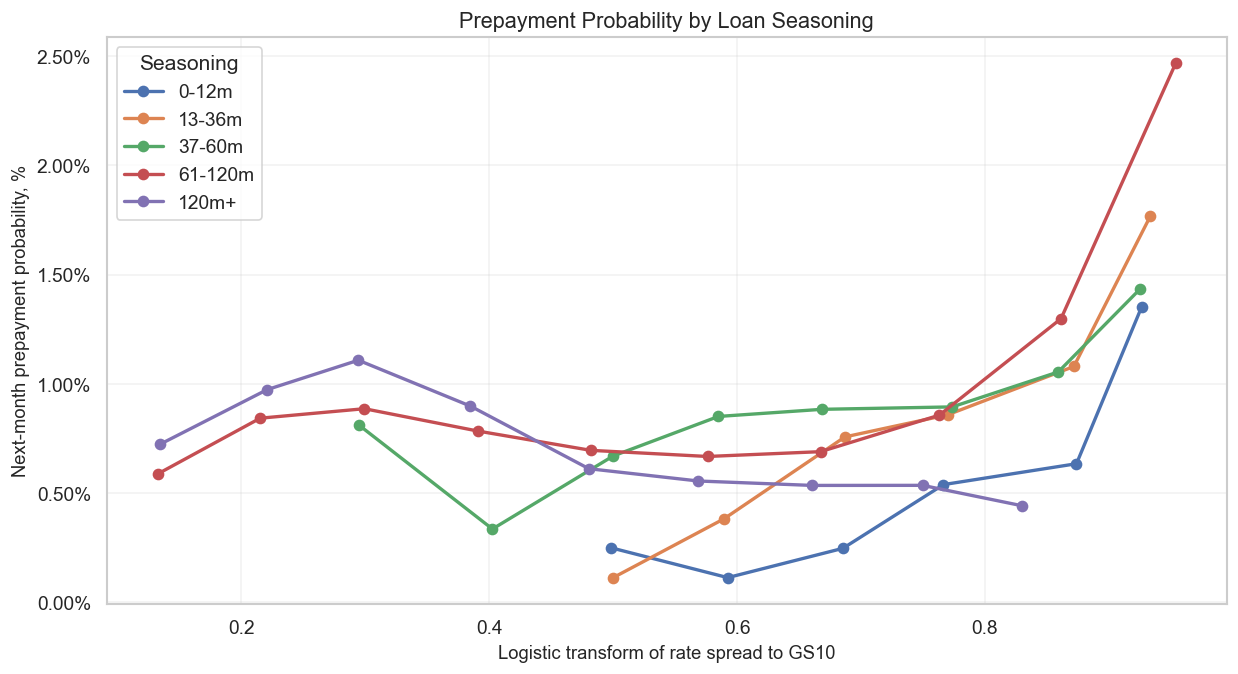

In [23]:
fig, ax = plt.subplots(figsize=(10.5, 5.8))

for bucket in seasoning_order:
    part = seasoning_curve[seasoning_curve["seasoning_bucket"] == bucket]
    if part.empty:
        continue
    ax.plot(part["x_mean"], part["smm_pct"], marker="o", linewidth=2, label=bucket)

ax.set_xlabel("Logistic transform of rate spread to GS10")
ax.set_ylabel("Next-month prepayment probability, %")
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f%%"))
ax.set_title("Prepayment Probability by Loan Seasoning")
ax.legend(title="Seasoning")
ax.grid(True, alpha=0.25)

fig.tight_layout()
plt.show()


## GS10 and logit spread

In [24]:
x_bucket, _ = make_bucket_col(df, ALT_RATE_COL, n_bins=10)
y_bucket, _ = make_bucket_col(df, LOGIT_SPREAD_COL, n_bins=10)

heat = (
    df.filter(F.col(ALT_RATE_COL).isNotNull() & F.col(LOGIT_SPREAD_COL).isNotNull())
    .withColumn("gs10_bucket", x_bucket)
    .withColumn("logit_bucket", y_bucket)
    .groupBy("gs10_bucket", "logit_bucket")
    .agg(
        F.count("*").alias("n"),
        F.avg(TARGET_COL).alias("smm"),
        F.avg(ALT_RATE_COL).alias("gs10_mean"),
        F.avg(LOGIT_SPREAD_COL).alias("logit_mean"),
    )
    .filter(F.col("n") >= 500)
    .toPandas()
)

heat["smm_pct"] = heat["smm"] * 100
display(heat.head())


,gs10_bucket,logit_bucket,n,smm,gs10_mean,logit_mean,smm_pct
0,7,4,259554,0.009173,3.729185,0.472020,0.917343
1,9,4,597725,0.005700,4.506724,0.476774,0.569995
2,8,3,384115,0.008976,4.184538,0.382039,0.897648
3,1,7,1414,0.009194,1.284321,0.781097,0.919378
4,4,7,2356354,0.007835,2.423686,0.758641,0.783541


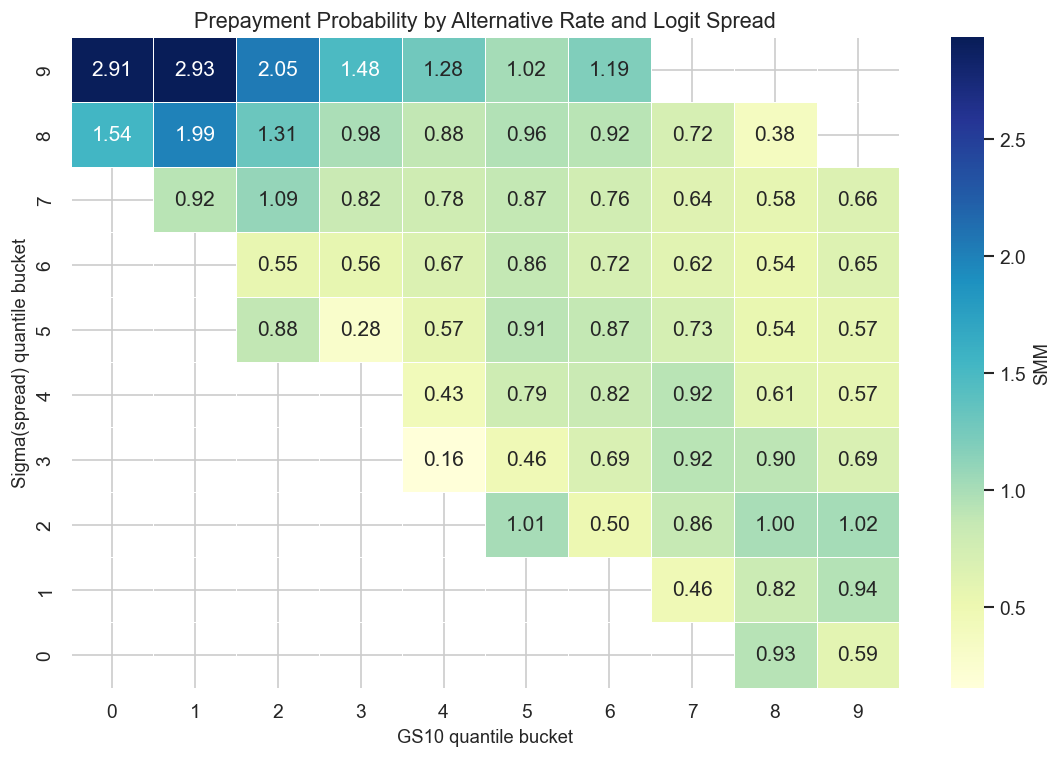

In [25]:
pivot = heat.pivot(index="logit_bucket", columns="gs10_bucket", values="smm_pct").sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(9.5, 6.5))
sns.heatmap(
    pivot,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    cbar_kws={"label": "SMM"},
    ax=ax,
)
ax.set_xlabel("GS10 quantile bucket")
ax.set_ylabel("Sigma(spread) quantile bucket")
ax.set_title("Prepayment Probability by Alternative Rate and Logit Spread")
fig.tight_layout()
plt.show()


## XGBoost features

In [26]:
fi_xgb = pd.read_csv(FEATURE_IMPORTANCE_PATH).sort_values("rank")
display(fi_xgb.head(25))

FI_TOP_N = 18
important_features = fi_xgb.head(FI_TOP_N)["feature"].tolist()

def raw_feature_name(feature):
    if feature in df.columns:
        return feature
    for base in ["month_of_year", "occupancy_status", "loan_purpose", "property_type", "fico_bucket", "seasoning_bucket", "channel", "vintage_year"]:
        prefix = f"{base}_"
        if feature.startswith(prefix) and base in df.columns:
            return base
    return None

important_raw_features = []
for feature in important_features:
    raw_feature = raw_feature_name(feature)
    if raw_feature is not None and raw_feature not in important_raw_features:
        important_raw_features.append(raw_feature)

,feature,weight,gain,cover,total_gain,gain_norm,rank
0,logit_rate_spread_to_10y,151.0,35790.480469,4745334.50,5.404362e+06,0.155984,1
1,rate_spread_to_10y,692.0,19285.343750,5292544.00,1.334546e+07,0.084051,2
2,orig_loan_term,27.0,18674.904297,4465833.50,5.042224e+05,0.081390,3
3,is_high_bal,151.0,17672.599609,7506248.00,2.668562e+06,0.077022,4
4,gs10_monthly,1144.0,10963.518555,7695038.00,1.254226e+07,0.047782,5
5,remaining_months_to_mat,792.0,8939.588867,7580607.50,7.080154e+06,0.038961,6
6,ph_delinq_count,328.0,8934.024414,3970772.25,2.930360e+06,0.038937,7
7,upb_fraction,898.0,8435.595703,5604308.00,7.575165e+06,0.036765,8
8,orig_upb,1574.0,7515.178711,4202143.50,1.182889e+07,0.032753,9
9,first_time_buyer,145.0,6198.076660,7178743.00,8.987211e+05,0.027013,10


In [27]:
NUMERIC_FEATURES_META = set(columns_meta.get("numeric_features", []))
CATEGORICAL_FEATURES_META = set(columns_meta.get("categorical_features", []))
BINARY_FEATURES_META = set(columns_meta.get("binary_features", []))

FEATURE_LABELS = {
    "logit_rate_spread_to_10y": "Logistic transform of rate spread to GS10",
    "rate_spread_to_10y": "Current mortgage rate minus GS10",
    "gs10_monthly": "10-year Treasury yield, GS10 (%)",
    "orig_loan_term": "Original loan term (months)",
    "is_high_bal": "High balance loan flag",
    "remaining_months_to_mat": "Remaining months to maturity",
    "ph_delinq_count": "Payment-history delinquency count",
    "upb_fraction": "Current UPB / original UPB",
    "orig_upb": "Original unpaid principal balance",
    "dti": "Debt-to-income ratio (DTI)",
    "first_time_buyer": "First-time buyer flag",
    "loan_age": "Loan age (months)",
    "age_sq": "Loan age squared / 100",
    "is_judicial_state": "Judicial foreclosure state flag",
    "spread_pos": "Positive spread to GS10",
    "occupancy_status": "Occupancy status",
    "loan_purpose": "Loan purpose",
    "property_type": "Property type",
    "pct_term_elapsed": "Share of loan term elapsed",
    "month_of_year": "Calendar month",
    "fico_bucket": "FICO bucket",
}

def feature_label(feature):
    return FEATURE_LABELS.get(feature, feature)


def plot_prepayment_by_category(feature, min_n=500, top_n=20):
    agg = (
        df.filter(F.col(feature).isNotNull())
        .groupBy(feature)
        .agg(
            F.count("*").alias("n"),
            F.sum(TARGET_COL).alias("n_prepaid"),
            F.avg(TARGET_COL).alias("smm"),
        )
        .filter(F.col("n") >= min_n)
        .orderBy(F.desc("n"))
        .limit(top_n)
        .toPandas()
    )

    if agg.empty:
        print(f"No data for {feature}")
        return

    agg["smm_pct"] = agg["smm"] * 100
    agg = agg.sort_values("smm_pct")

    fig, ax = plt.subplots(figsize=(9.5, max(4.2, 0.38 * len(agg))))
    ax.barh(agg[feature].astype(str), agg["smm_pct"], color="#457b9d", alpha=0.88)
    ax.set_xlabel("Next-month prepayment probability (SMM, %)")
    ax.set_ylabel(feature_label(feature))
    ax.set_title(f"Prepayment Probability by {feature_label(feature)}")
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f%%"))
    ax.grid(True, axis="x", alpha=0.25)
    fig.tight_layout()
    plt.show()


def plot_relation_for_feature(feature):
    if feature in BINARY_FEATURES_META or feature in CATEGORICAL_FEATURES_META:
        plot_prepayment_by_category(feature)
        return

    if feature in NUMERIC_FEATURES_META:
        agg, _ = aggregate_rate_curve(df, feature, n_bins=14, min_n=1000)
        display(agg[["bucket", "bucket_label", "n", "n_prepaid", "smm_pct", "cpr_pct"]])
        plot_rate_curve(
            agg,
            x_label=feature_label(feature),
            title=f"Prepayment Probability by {feature_label(feature)}",
            color="#2a9d8f",
        )
        return

    plot_prepayment_by_category(feature)


,bucket,bucket_label,n,n_prepaid,smm_pct,cpr_pct
0,0,0.12,1178,8.0,0.679117,7.851800
1,1,0.19,35148,263.0,0.748264,8.618704
2,2,0.26,232096,2117.0,0.912123,10.412729
3,3,0.33,564138,5794.0,1.027054,11.651743
4,4,0.39,555405,4839.0,0.871256,9.968344
5,5,0.46,867168,6436.0,0.742186,8.551524
6,6,0.53,1352614,8800.0,0.650592,7.533718
7,7,0.59,1894435,12117.0,0.639610,7.410991
8,8,0.66,2177131,15398.0,0.707261,8.164650
9,9,0.73,2935113,20610.0,0.702188,8.108325


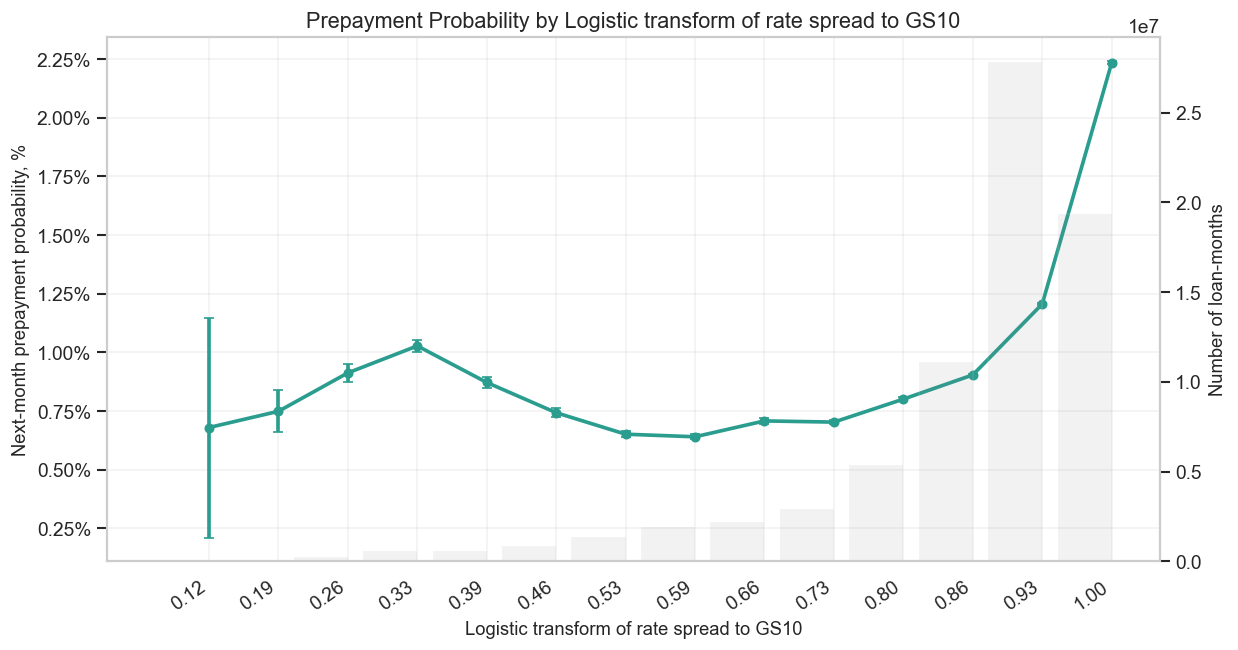

,bucket,bucket_label,n,n_prepaid,smm_pct,cpr_pct
0,1,-1.58,15482,106.0,0.684666,7.913559
1,2,-0.97,391045,3765.0,0.962805,10.961058
2,3,-0.36,1238200,11184.0,0.903247,10.316383
3,4,0.26,2992560,19589.0,0.654590,7.578359
4,5,0.87,4701329,32538.0,0.692102,7.996264
5,6,1.48,8963928,72787.0,0.811999,9.320387
6,7,2.09,18119916,169294.0,0.934298,10.653024
7,8,2.70,22064211,311463.0,1.411621,15.684248
8,9,3.31,10781527,222405.0,2.062834,22.129961
9,10,3.92,3815751,114389.0,2.997811,30.596971


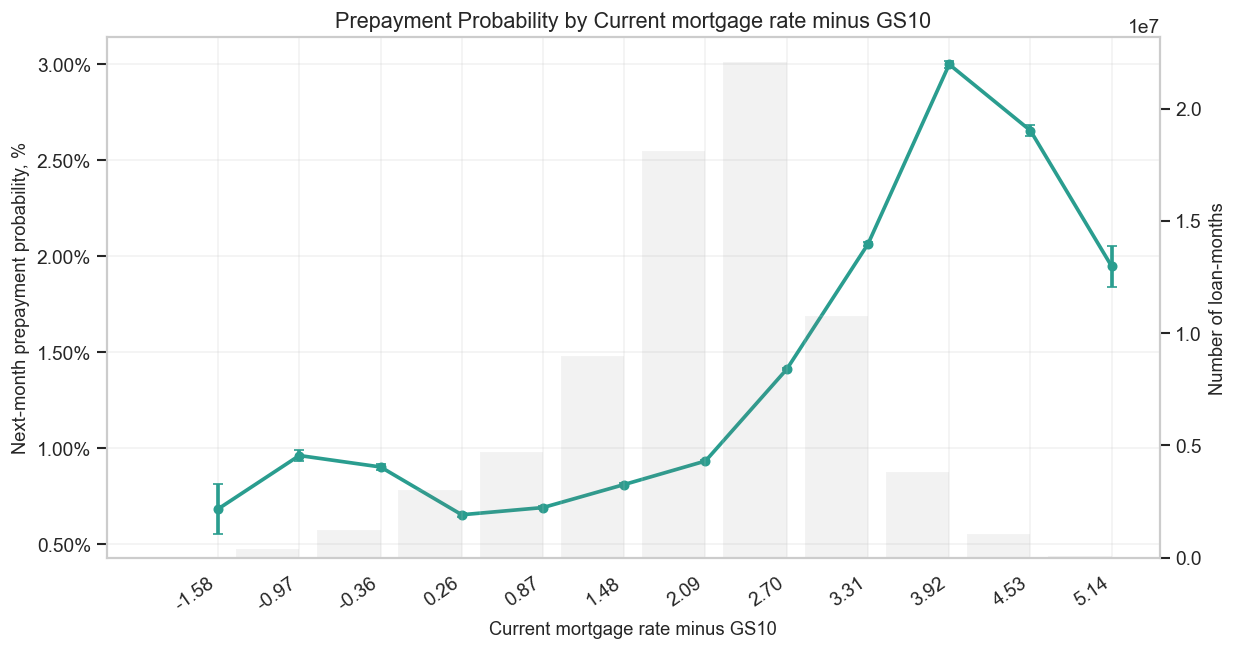

,bucket,bucket_label,n,n_prepaid,smm_pct,cpr_pct
0,0,192.86,16902869,175231.0,1.036694,11.754951
1,13,360.00,57292261,811306.0,1.416083,15.730031


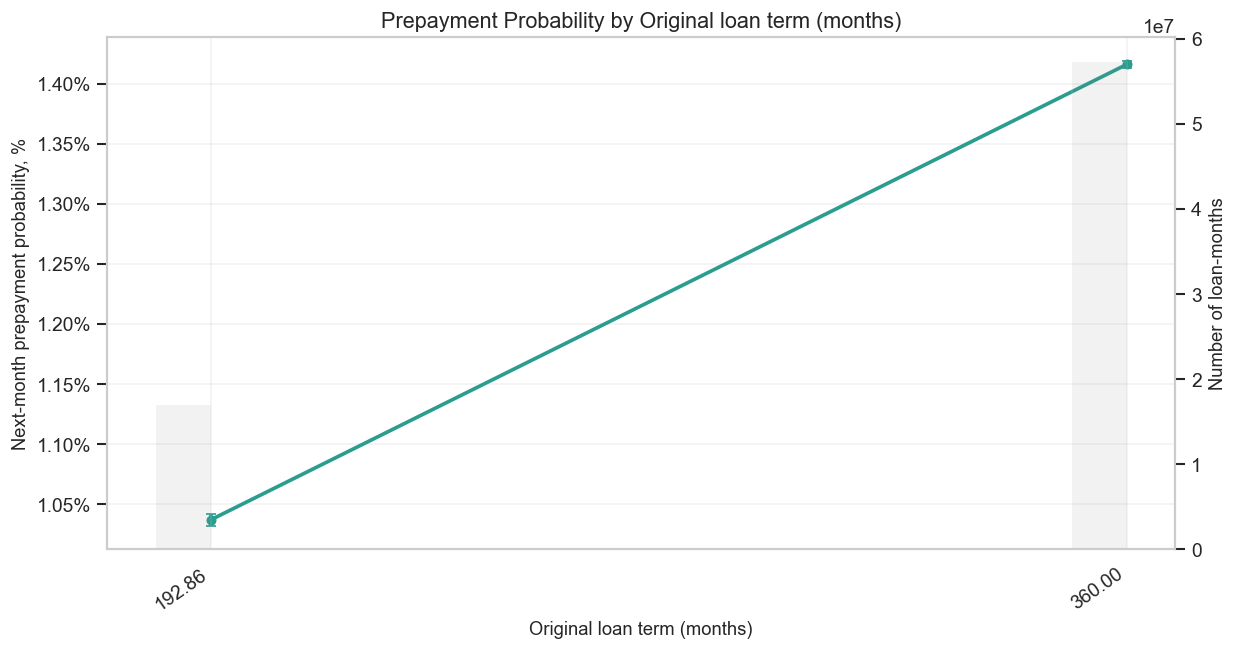

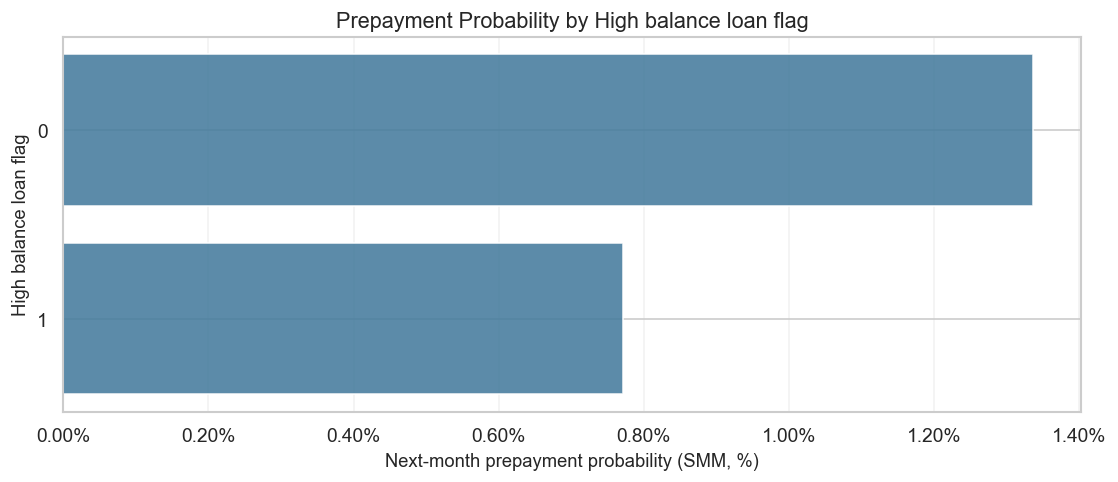

,bucket,bucket_label,n,n_prepaid,smm_pct,cpr_pct
0,0,0.92,4114063,119787.0,2.911647,29.853566
1,1,1.22,761579,21600.0,2.836213,29.196746
2,2,1.52,2993209,71490.0,2.388407,25.180151
3,3,1.81,11314314,216806.0,1.916210,20.719410
4,4,2.11,9384133,127628.0,1.360040,15.153364
5,5,2.41,18820914,207864.0,1.104431,12.477038
6,6,2.71,8925794,76304.0,0.854871,9.789602
7,7,3.01,8306405,77455.0,0.932473,10.633273
8,8,3.31,1503903,12417.0,0.825652,9.470053
9,9,3.61,955738,6990.0,0.731372,8.431893


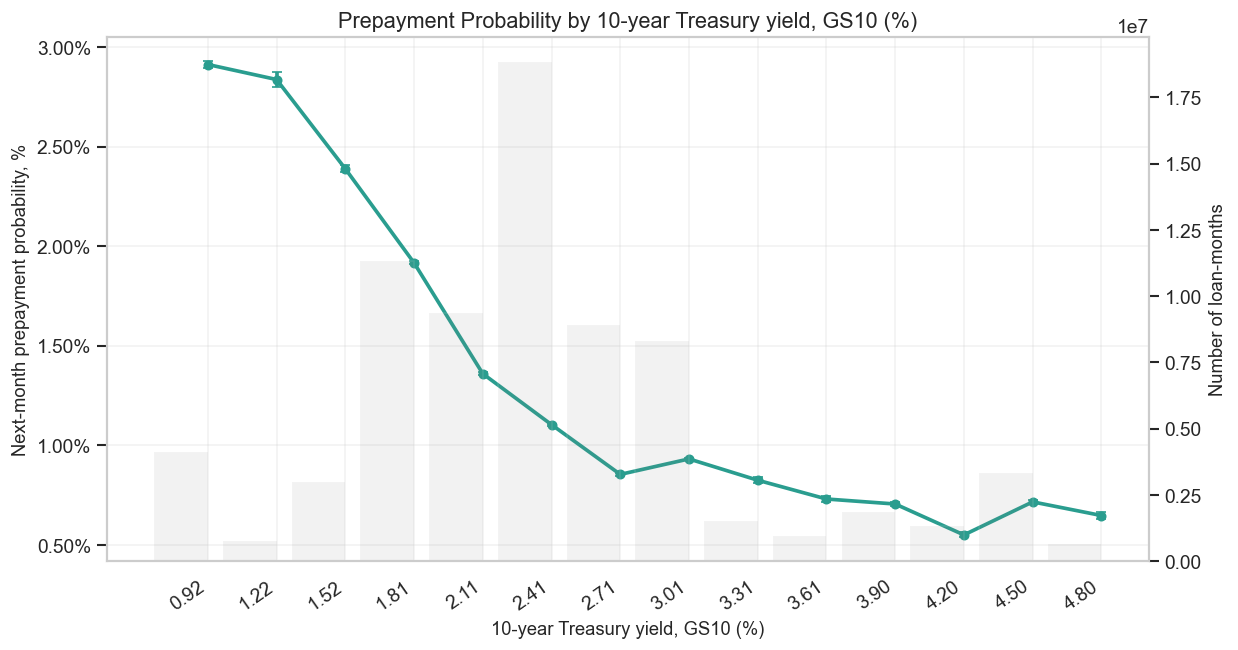

,bucket,bucket_label,n,n_prepaid,smm_pct,cpr_pct
0,0,34.50,595957,45229.0,7.589306,61.214733
1,1,69.00,2035947,20236.0,0.993936,11.296334
2,2,103.50,3131063,36645.0,1.170369,13.174744
3,3,138.00,4482734,41806.0,0.932601,10.634651
4,4,172.50,6398342,58335.0,0.911721,10.408368
5,5,207.00,2392053,15587.0,0.651616,7.545152
6,6,241.50,3292527,26657.0,0.809621,9.294300
7,7,276.00,6107355,95381.0,1.561740,17.212047
8,8,310.50,12592920,220572.0,1.751556,19.107512
9,9,345.00,19844455,292953.0,1.476246,16.345096


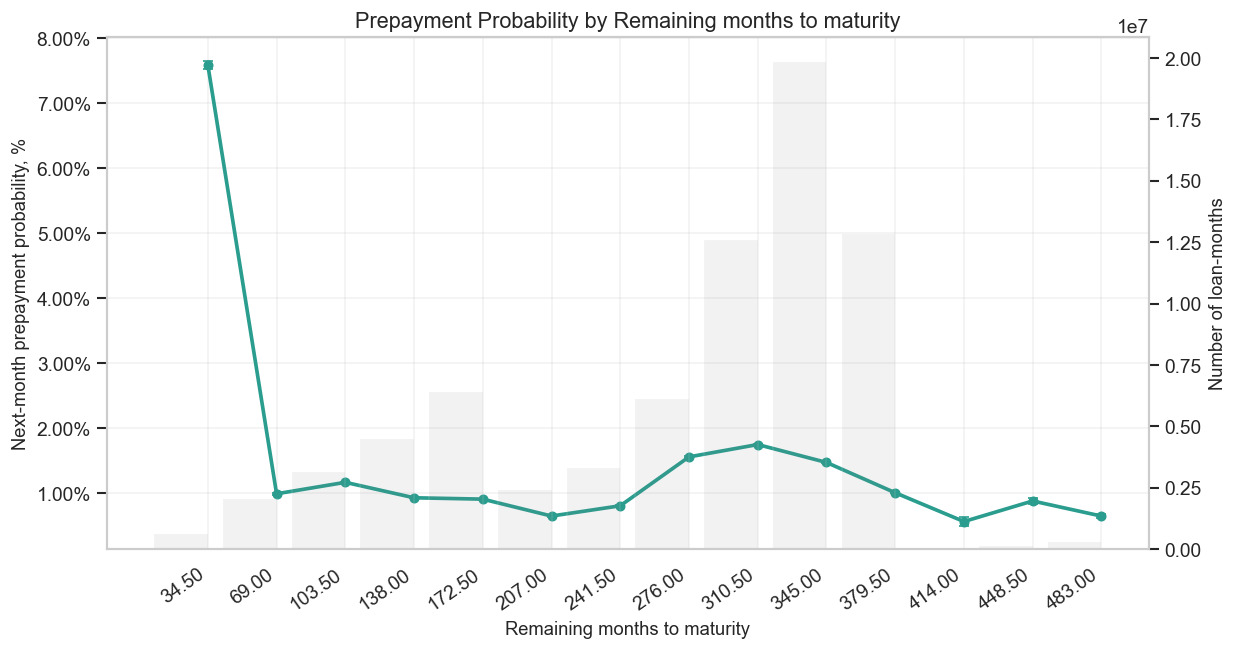

,bucket,bucket_label,n,n_prepaid,smm_pct,cpr_pct
0,0,1.71,56236844,680743.0,1.210493,13.596801
1,1,3.43,38943,274.0,0.703592,8.123924
2,2,5.14,46772,343.0,0.733345,8.453728
3,3,6.86,28073,226.0,0.805044,9.244058
4,4,8.57,64317,535.0,0.831817,9.537570
5,5,10.29,71590,657.0,0.917726,10.473504
6,6,12.00,39354,396.0,1.006251,11.428650
7,7,13.71,93569,1017.0,1.086898,12.290661
8,8,15.43,99933,1114.0,1.114747,12.586531
9,9,17.14,121751,1536.0,1.261591,14.131577


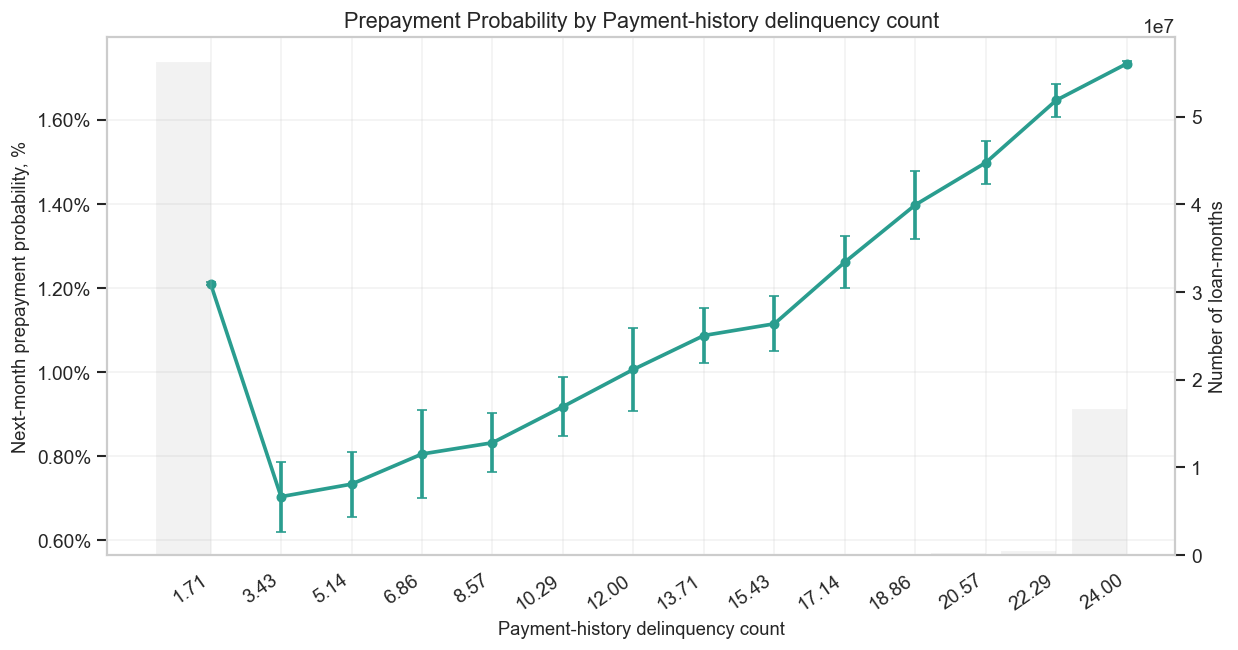

,bucket,bucket_label,n,n_prepaid,smm_pct,cpr_pct
0,0,0.15,360754,40057.0,11.103688,75.644059
1,1,0.29,776497,13760.0,1.772061,19.309875
2,2,0.44,1845130,16802.0,0.910613,10.396354
3,3,0.59,2531964,26654.0,1.052701,11.926076
4,4,0.73,4379047,47622.0,1.087497,12.297028
5,5,0.88,15285288,210271.0,1.375643,15.314274
6,6,1.03,48955945,631077.0,1.289071,14.417916
7,7,1.18,53575,273.0,0.509566,5.946296
8,8,1.32,5581,15.0,0.268769,3.177977
9,9,1.47,1005,6.0,0.597015,6.933557


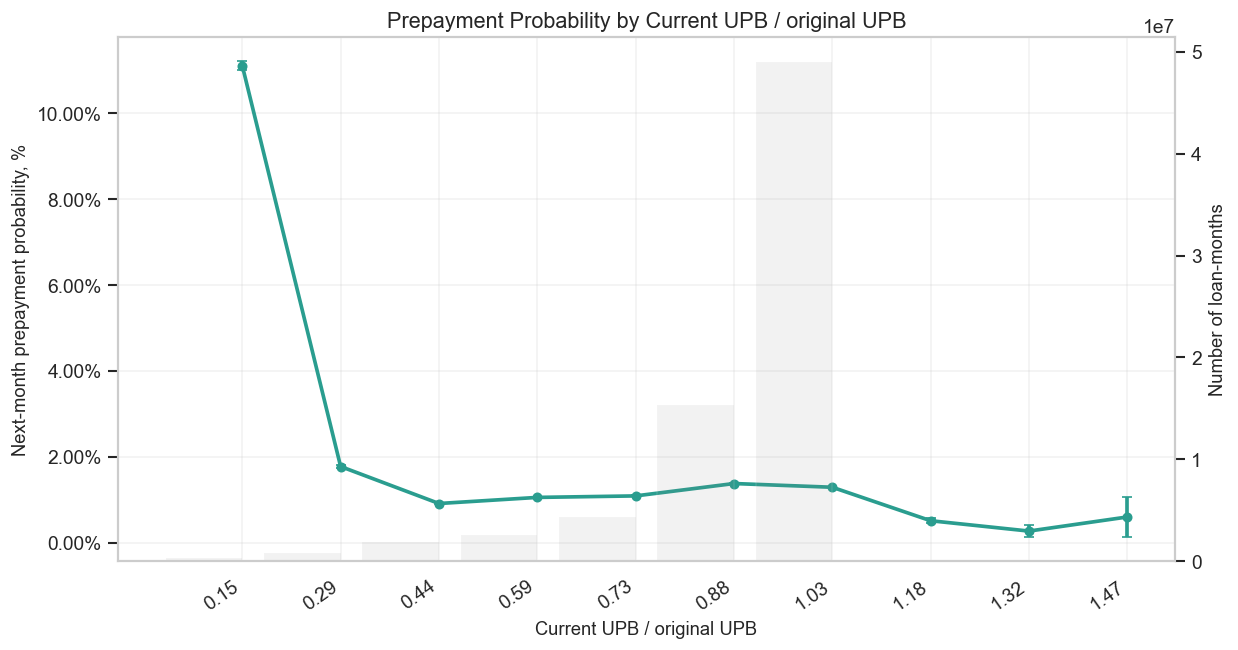

,bucket,bucket_label,n,n_prepaid,smm_pct,cpr_pct
0,0,93357.14,11601076,106529.0,0.918268,10.479384
1,1,178714.29,27213715,308477.0,1.133535,12.785626
2,2,264071.43,18092183,257093.0,1.421017,15.780628
3,3,349428.57,9439171,158258.0,1.676609,18.363914
4,4,434785.71,6137870,116268.0,1.894273,20.506369
5,5,520142.86,932431,20596.0,2.208850,23.511763
6,6,605500.00,511435,12717.0,2.486533,26.077751
7,7,690857.14,237388,6160.0,2.594908,27.057619
8,8,776214.29,16521,206.0,1.246898,13.978113
9,9,861571.43,10432,176.0,1.687117,18.468543


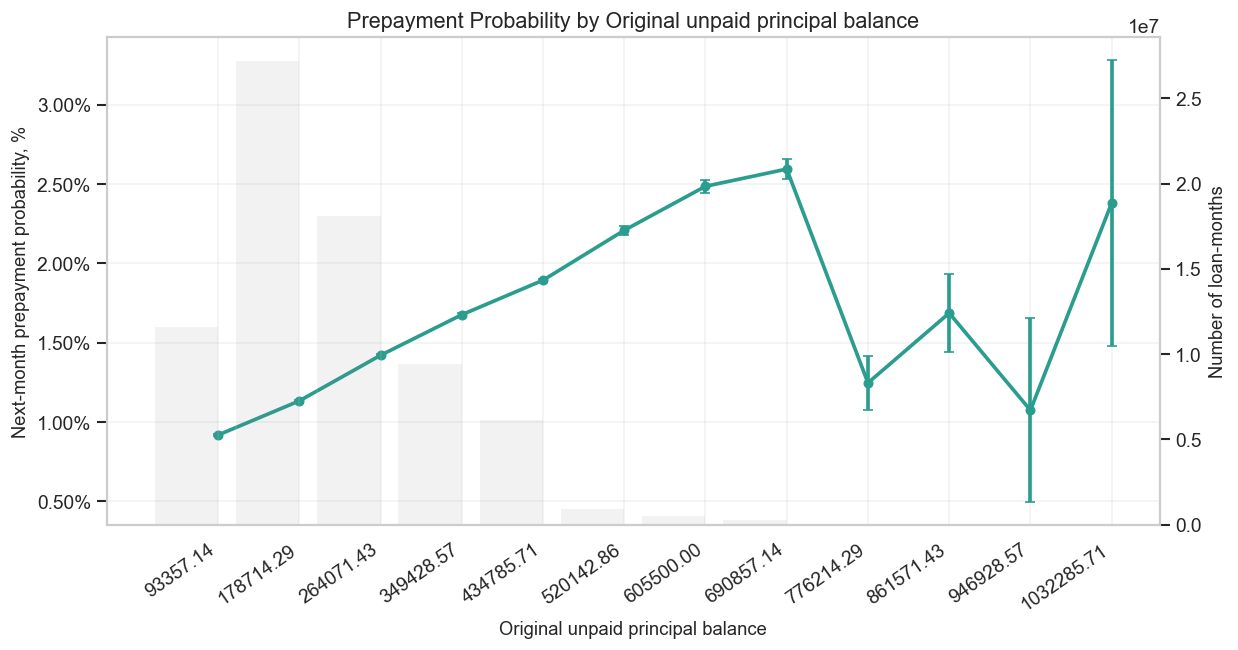

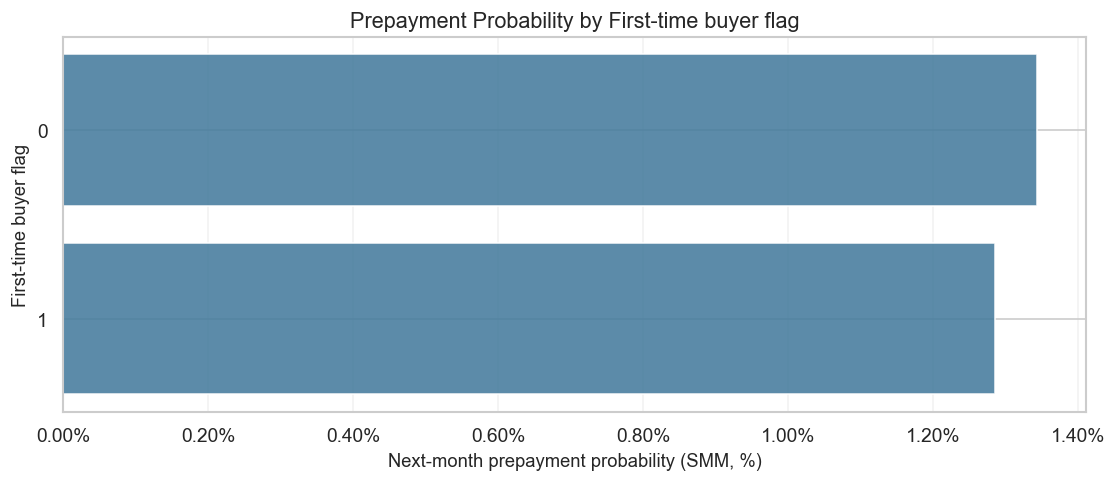

,bucket,bucket_label,n,n_prepaid,smm_pct,cpr_pct
0,0,11.36,13292645,117840.0,0.886505,10.134401
1,1,22.71,11051051,142155.0,1.286348,14.389582
2,2,34.07,10060658,165509.0,1.645111,18.049534
3,3,45.43,7839323,91501.0,1.167205,13.141383
4,4,56.79,6963006,66611.0,0.956641,10.894542
5,5,68.14,6673488,98619.0,1.477773,16.360651
6,6,79.50,4771488,134370.0,2.816103,29.020696
7,7,90.86,3477306,87009.0,2.502196,26.220106
8,8,102.21,3069542,35032.0,1.141278,12.867552
9,9,113.57,2543639,17424.0,0.685003,7.917307


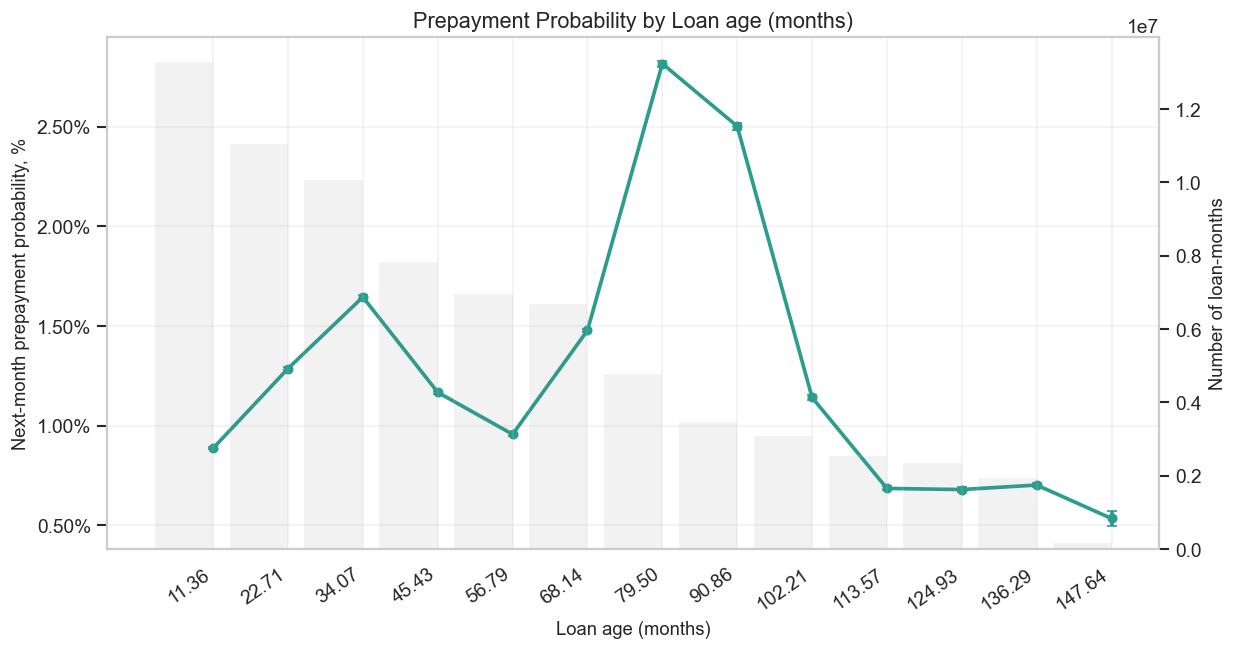

,bucket,bucket_label,n,n_prepaid,smm_pct,cpr_pct
0,0,18.06,40204746,494436.0,1.229795,13.799168
1,1,36.12,11350316,117983.0,1.039469,11.784640
2,2,54.17,6688061,131641.0,1.968298,21.223172
3,3,72.23,4110016,120892.0,2.941400,30.111087
4,4,90.29,3109253,58201.0,1.871864,20.288209
5,5,108.35,2213574,18885.0,0.853145,9.770759
6,6,126.40,1842813,12595.0,0.683466,7.900206
7,7,144.46,1745087,11717.0,0.671428,7.766156
8,8,162.52,1447852,10101.0,0.697654,8.057968
9,9,180.58,1167177,8189.0,0.701607,8.101881


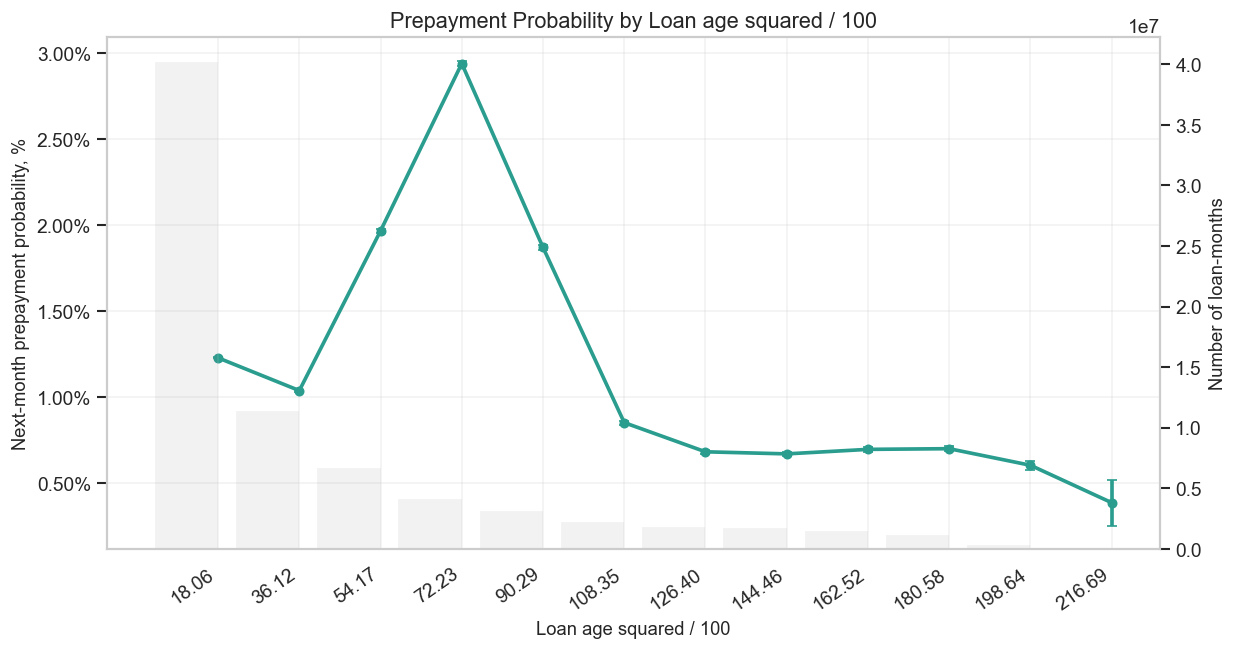

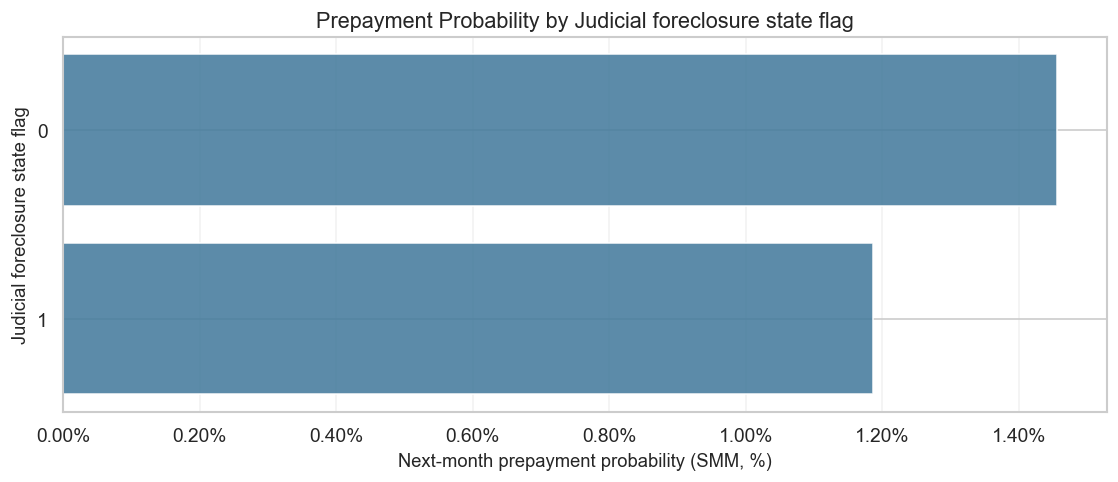

,bucket,bucket_label,n,n_prepaid,smm_pct,cpr_pct
0,0,0.41,5650118,41468.0,0.733932,8.460222
1,1,0.82,3282172,22886.0,0.697282,8.053835
2,2,1.23,4905589,36864.0,0.751469,8.654107
3,3,1.64,7984020,71945.0,0.901112,10.293203
4,4,2.06,13158085,122310.0,0.929543,10.601544
5,5,2.47,15842494,195509.0,1.234080,13.844029
6,6,2.88,12477410,223302.0,1.789650,19.483091
7,7,3.29,5812442,124951.0,2.149716,22.954890
8,8,3.70,2886681,84475.0,2.926371,29.981117
9,9,4.11,1702855,51502.0,3.024450,30.825344


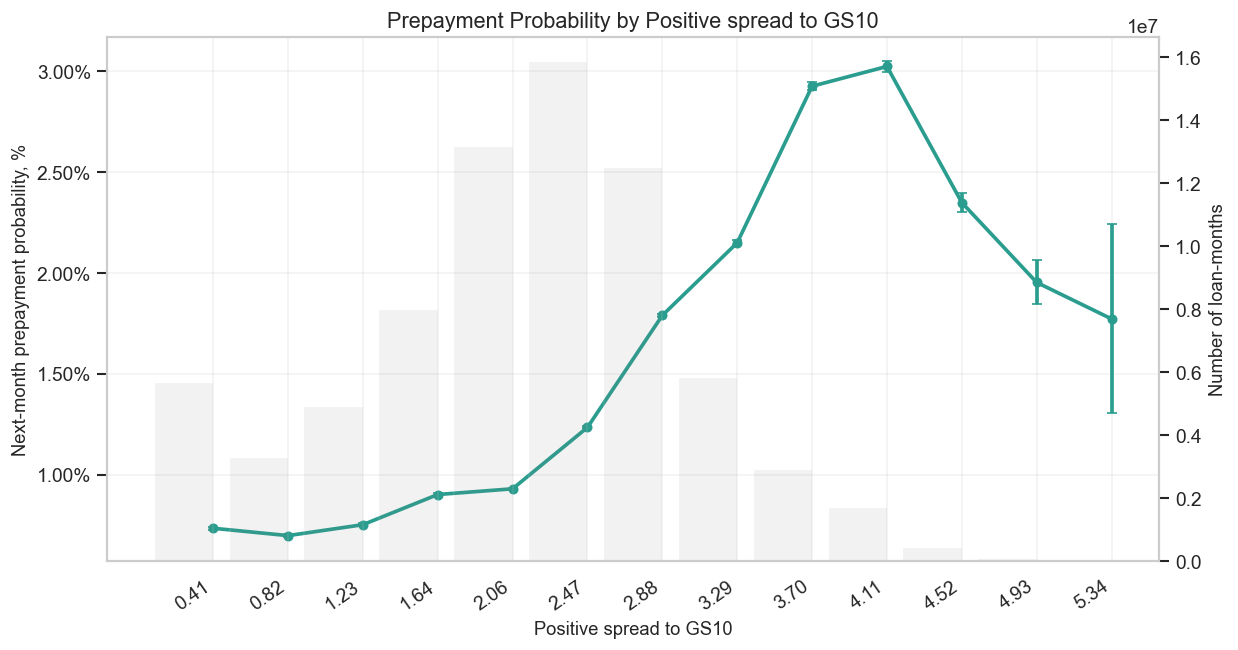

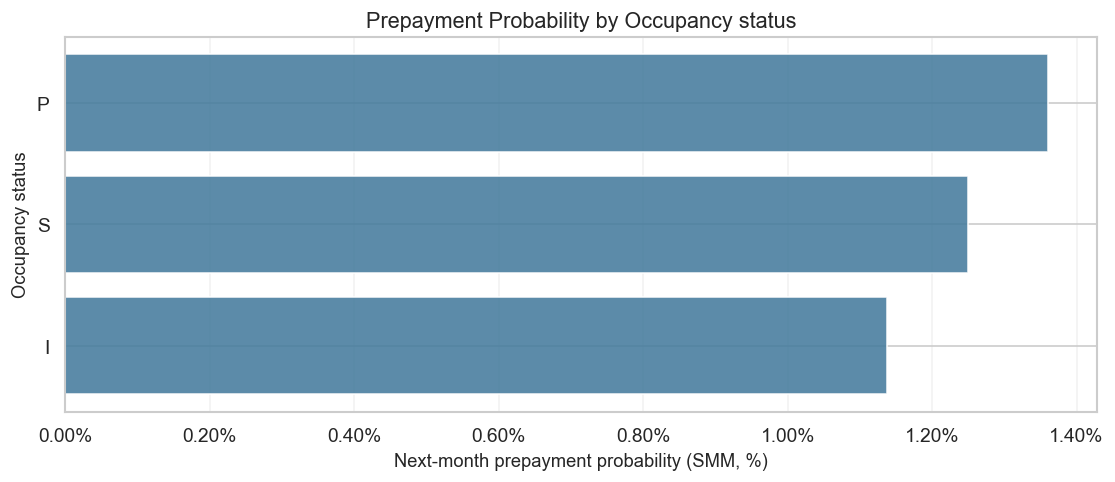

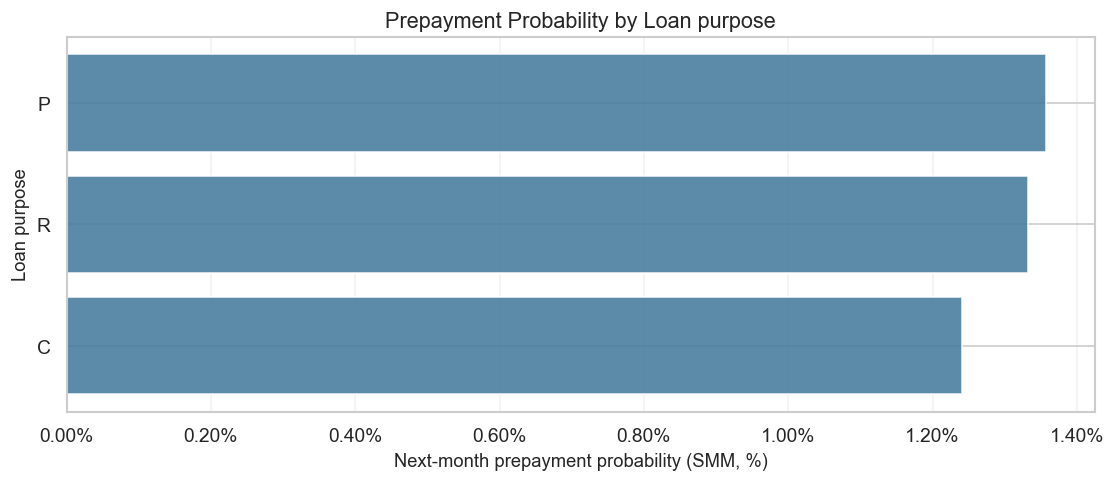

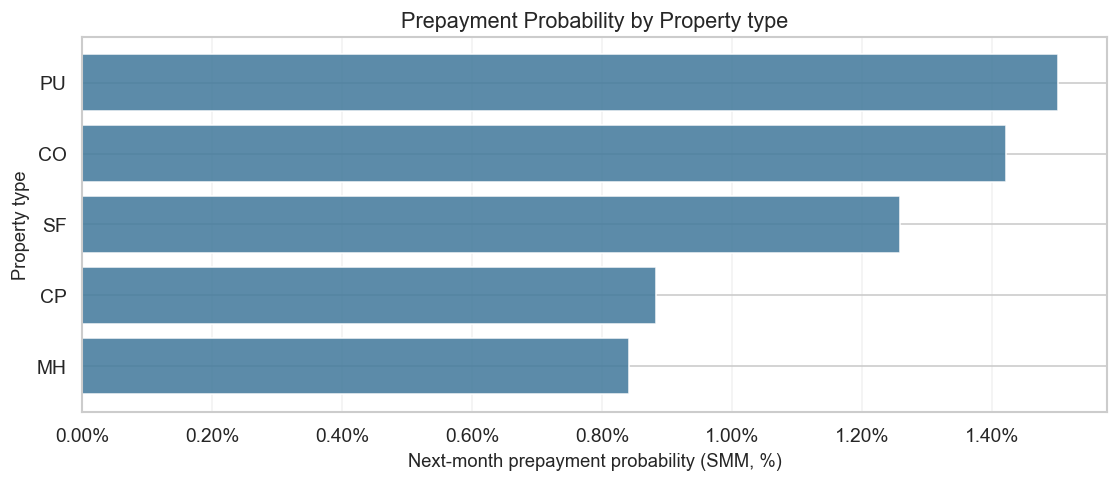

In [28]:
for feature in important_raw_features:
    plot_relation_for_feature(feature)


## Feature distributions for important variables

In [29]:
def aggregate_feature_distribution(feature, n_bins=16, min_n=1):
    if feature in NUMERIC_FEATURES_META and feature not in BINARY_FEATURES_META:
        bucket_col, cuts = make_bucket_col(df, feature, n_bins=n_bins)
        dist = (
            df.filter(F.col(feature).isNotNull())
            .withColumn("bucket", bucket_col)
            .groupBy("bucket")
            .agg(
                F.count("*").alias("n"),
                F.avg(feature).alias("x_mean"),
                F.min(feature).alias("x_min"),
                F.max(feature).alias("x_max"),
            )
            .filter(F.col("n") >= min_n)
            .orderBy("bucket")
            .toPandas()
        )
        if not dist.empty:
            if len(cuts) == n_bins + 1:
                edges = pd.DataFrame({
                    "bucket": range(n_bins),
                    "x_left": cuts[:-1],
                    "x_right": cuts[1:],
                })
                dist = dist.merge(edges, on="bucket", how="left")
                dist["label"] = dist.apply(lambda r: f"{r['x_right']:.2f}", axis=1)
            else:
                dist["label"] = dist.apply(lambda r: f"{r['x_max']:.2f}", axis=1)
        return dist

    dist = (
        df.filter(F.col(feature).isNotNull())
        .groupBy(feature)
        .agg(F.count("*").alias("n"))
        .orderBy(F.desc("n"))
        .limit(25)
        .toPandas()
    )
    if not dist.empty:
        dist["label"] = dist[feature].astype(str)
    return dist


def plot_feature_distribution(feature):
    dist = aggregate_feature_distribution(feature)
    if dist.empty:
        print(f"No distribution data for {feature}")
        return

    dist["share_pct"] = dist["n"] / dist["n"].sum() * 100

    fig, ax = plt.subplots(figsize=(10.5, 4.8))
    if "x_right" in dist.columns:
        x_pos = dist["x_right"].to_numpy()
        widths = (dist["x_right"] - dist["x_left"]).replace(0, np.nan)
        bar_width = float(widths.median()) * 0.78
        tick_labels = [f"{x:.2f}" for x in x_pos]
        ax.bar(x_pos, dist["share_pct"], width=-bar_width, align="edge", color="#6a994e", alpha=0.88)
    elif "x_max" in dist.columns:
        x_pos = dist["x_max"].to_numpy()
        widths = (dist["x_max"] - dist["x_min"]).replace(0, np.nan)
        bar_width = float(widths.median()) * 0.78
        tick_labels = [f"{x:.2f}" for x in x_pos]
        ax.bar(x_pos, dist["share_pct"], width=-bar_width, align="edge", color="#6a994e", alpha=0.88)
    else:
        x_pos = np.arange(len(dist))
        tick_labels = dist["label"].tolist()
        ax.bar(x_pos, dist["share_pct"], color="#6a994e", alpha=0.88)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right")
    ax.set_xlabel(feature_label(feature))
    ax.set_ylabel("Share of loan-months, %")
    ax.set_title(f"Distribution of {feature_label(feature)}")
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
    ax.grid(True, axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()


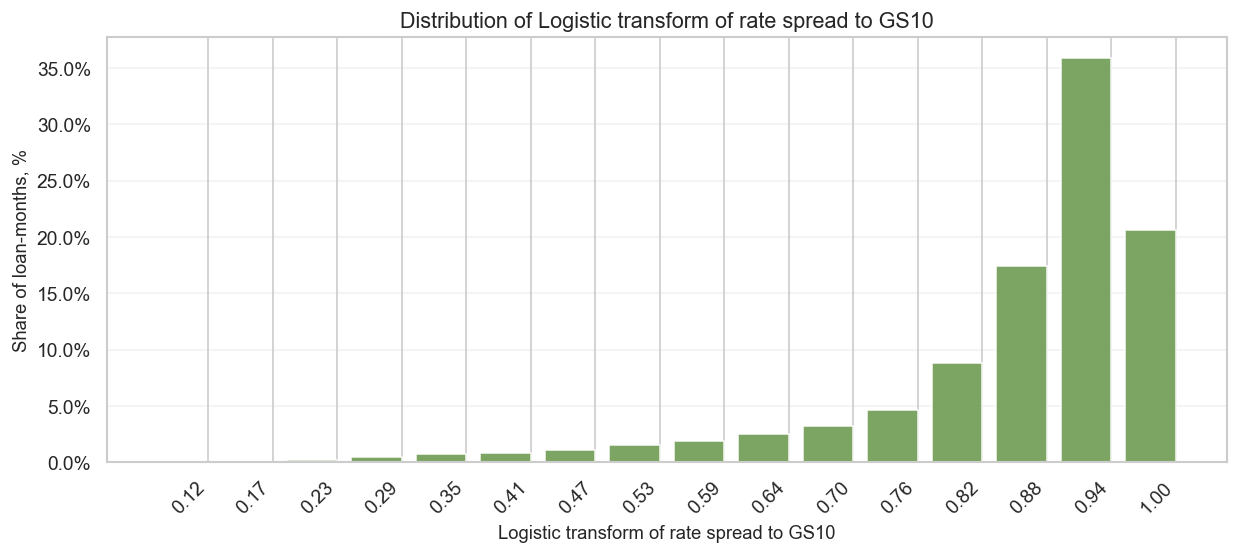

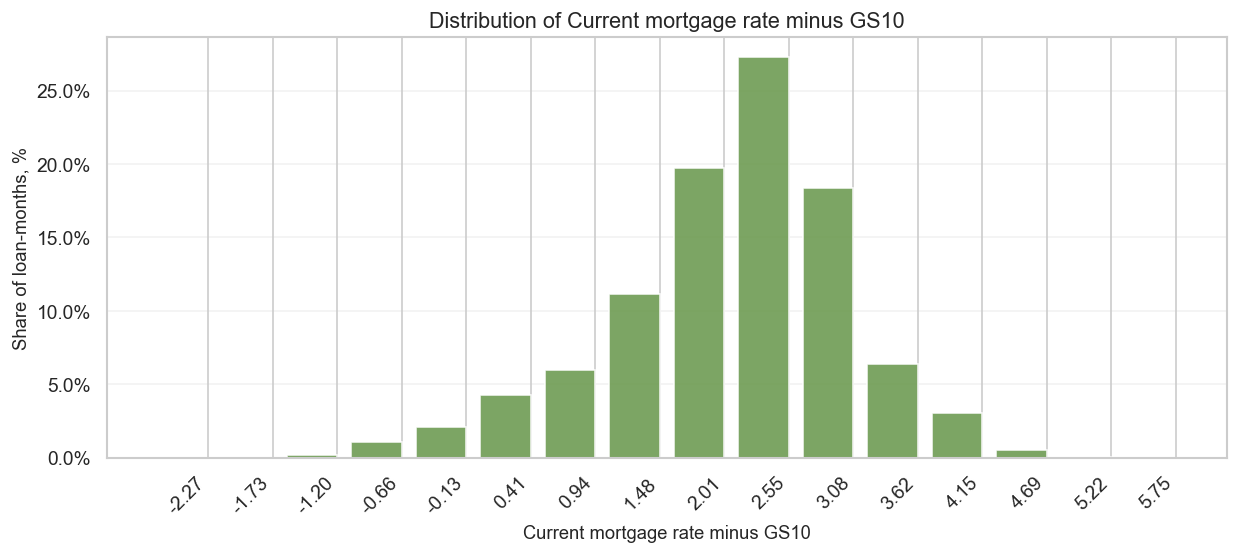

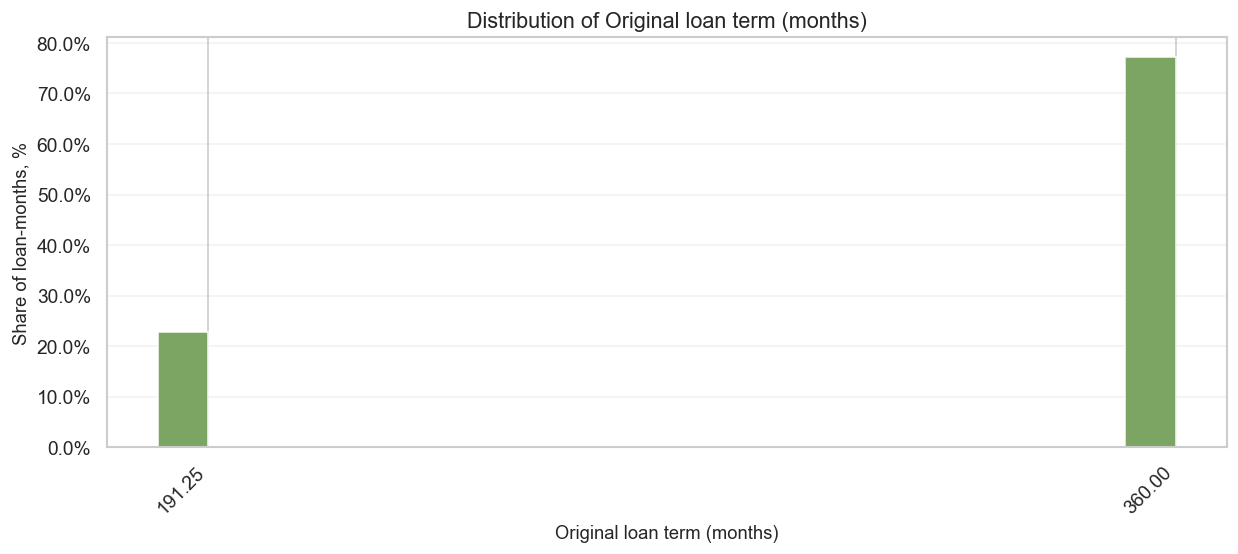

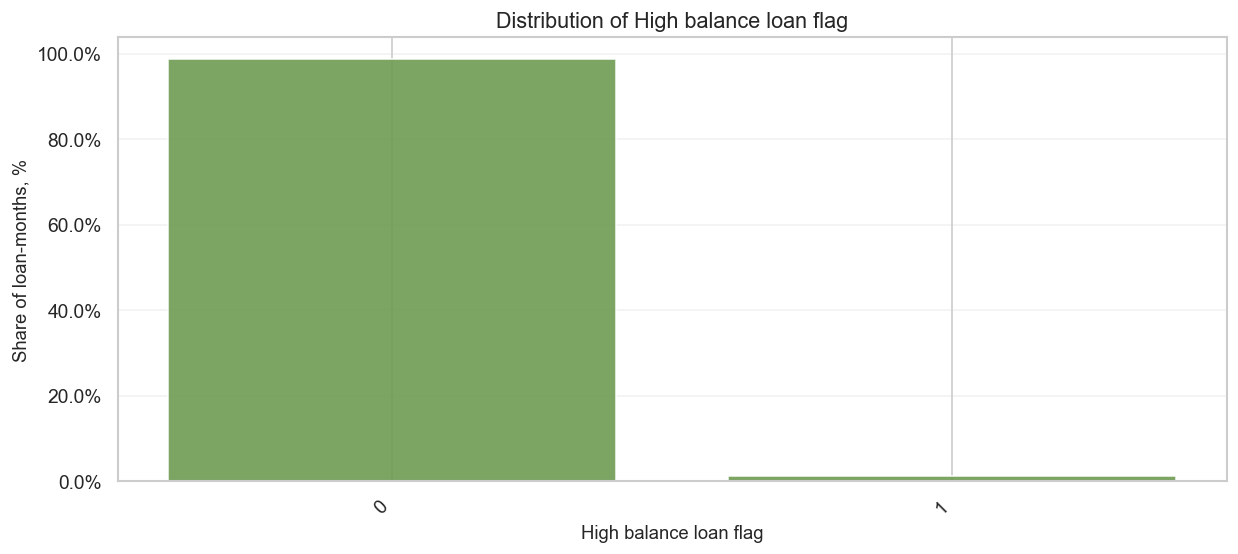

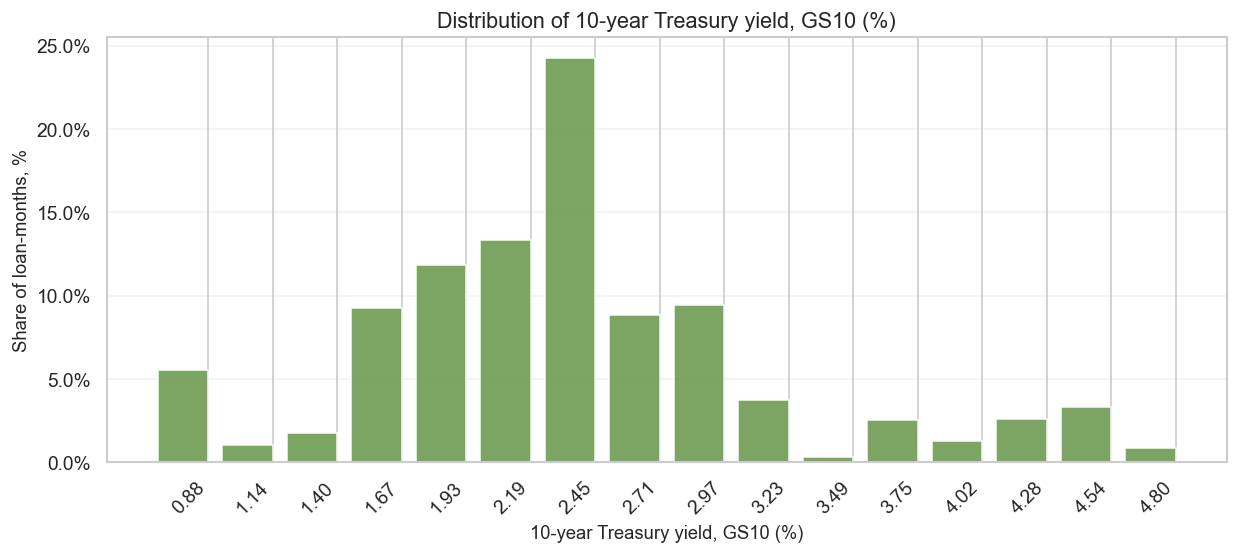

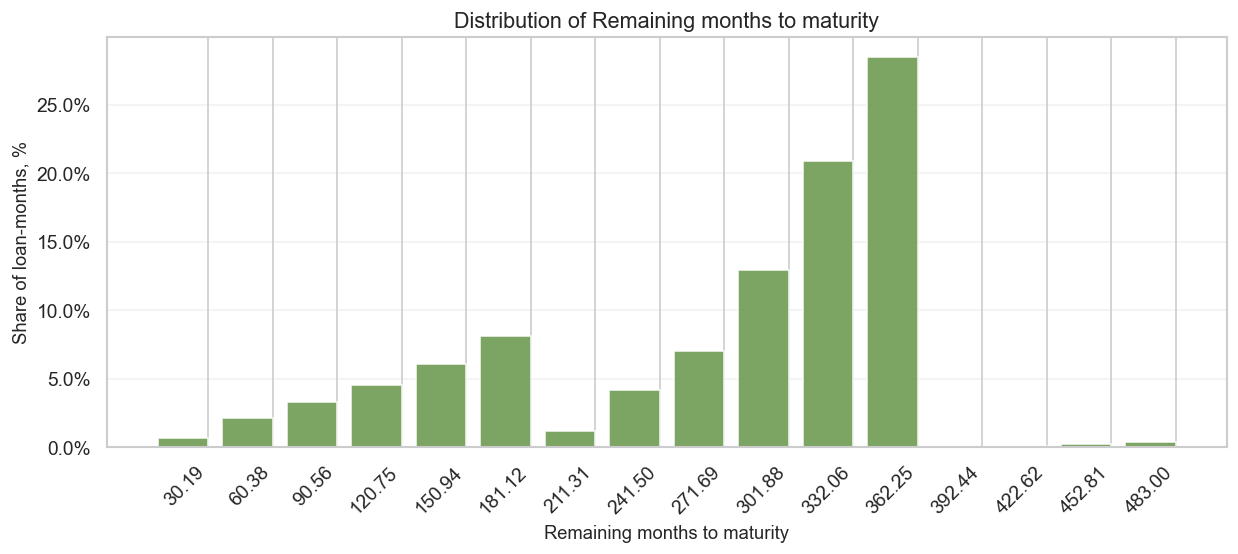

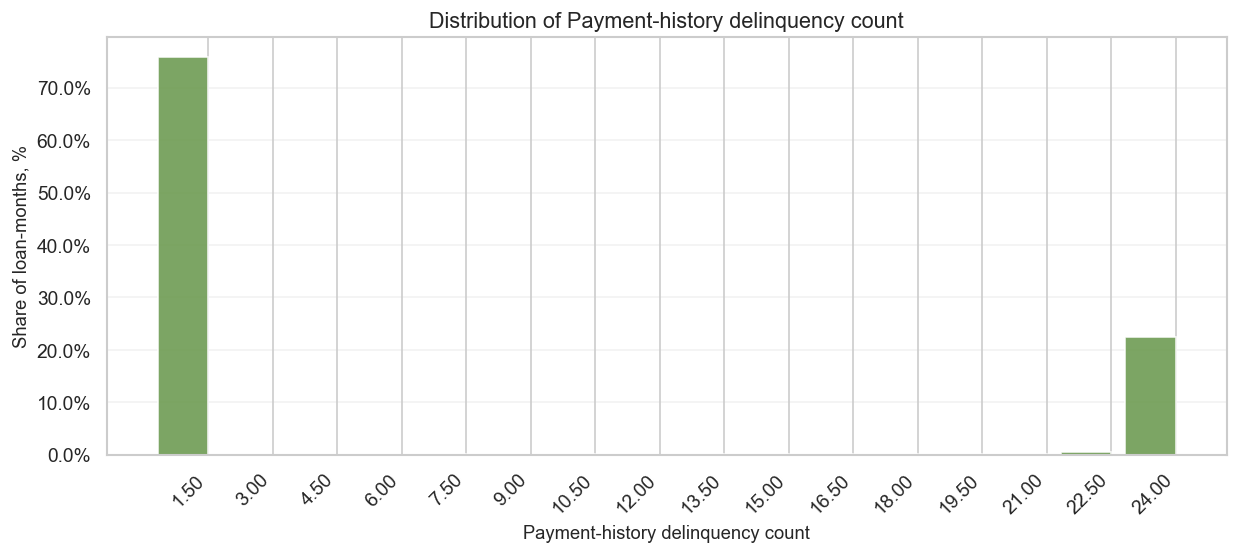

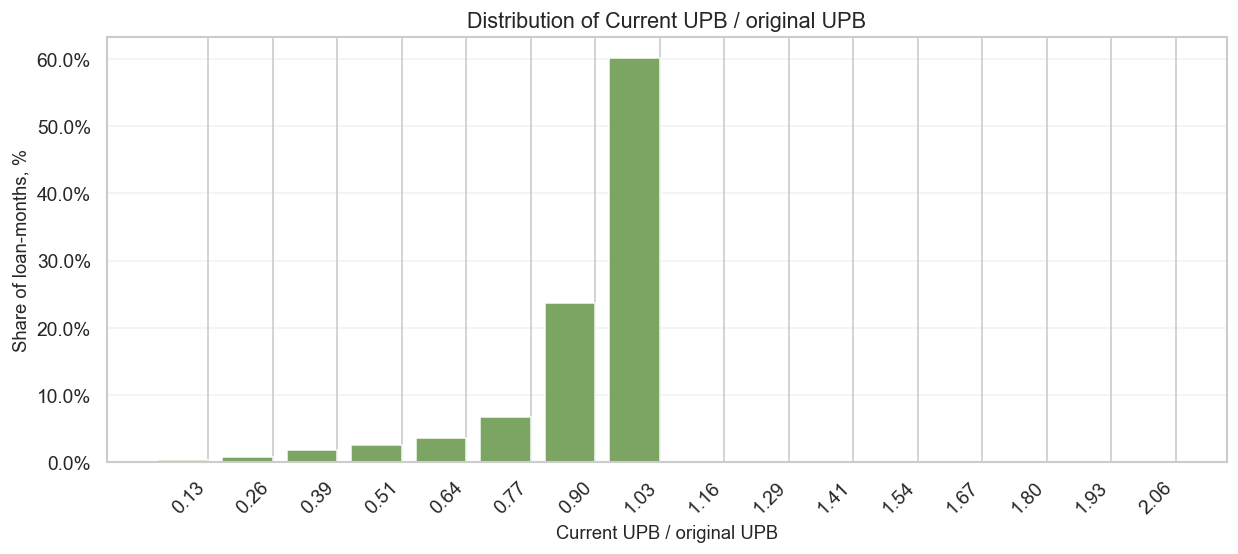

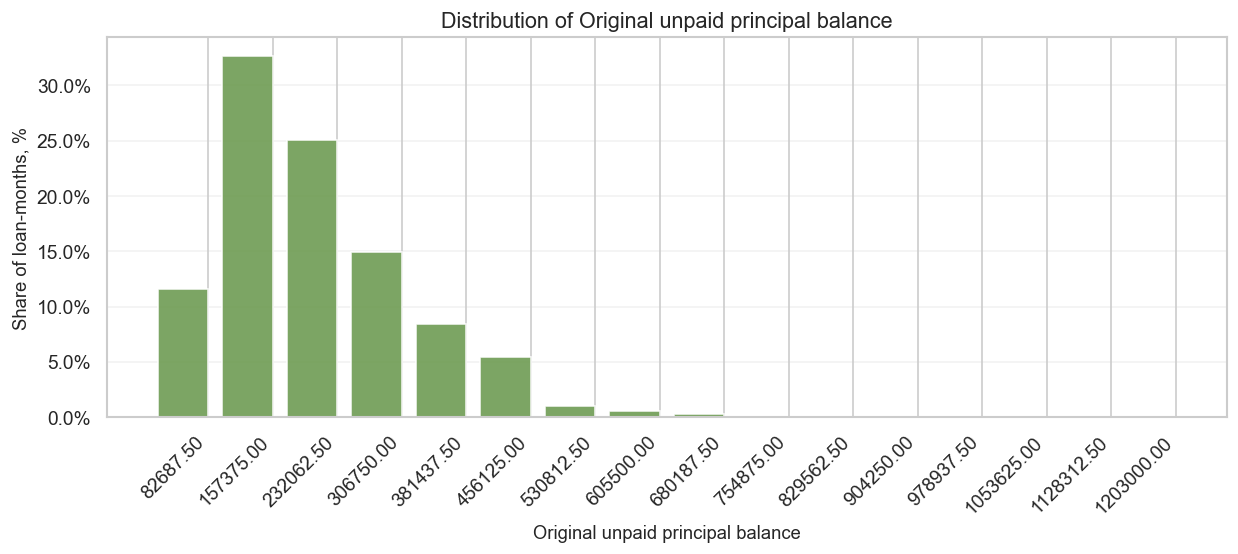

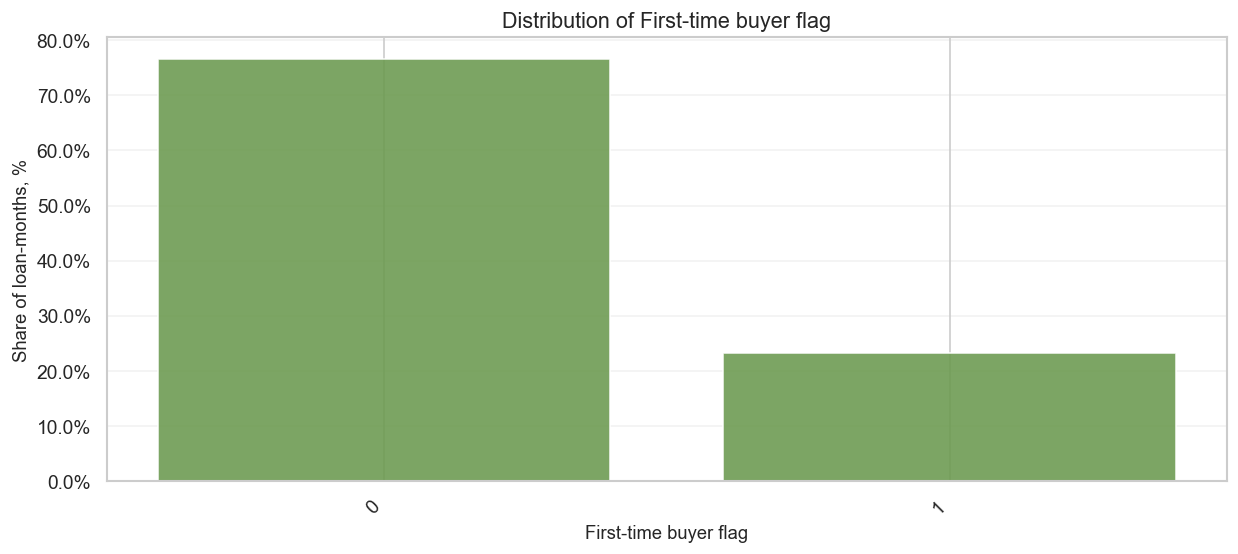

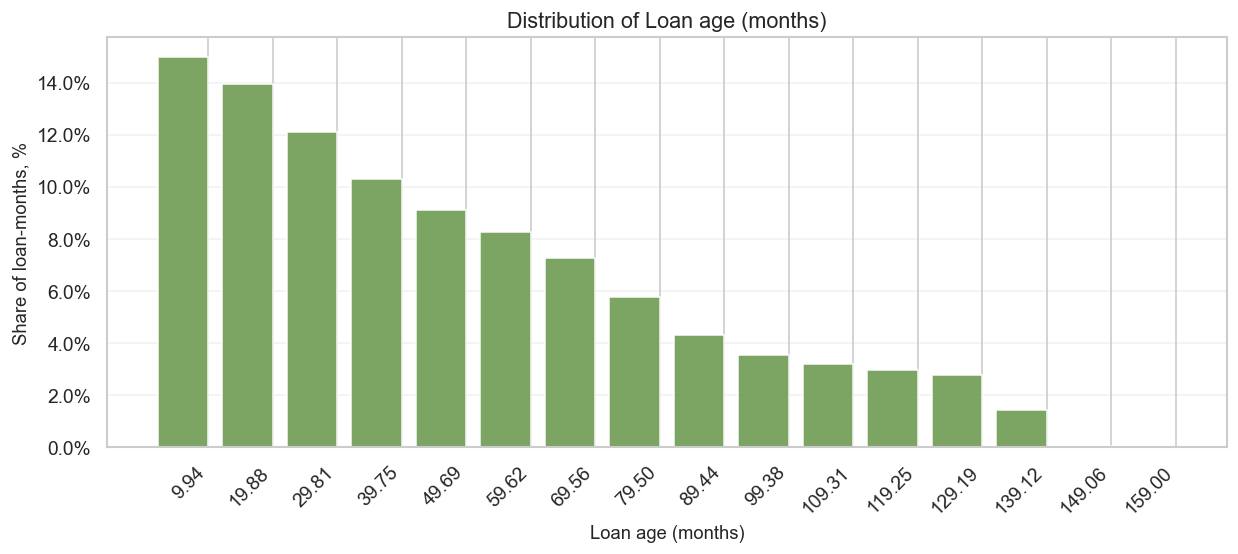

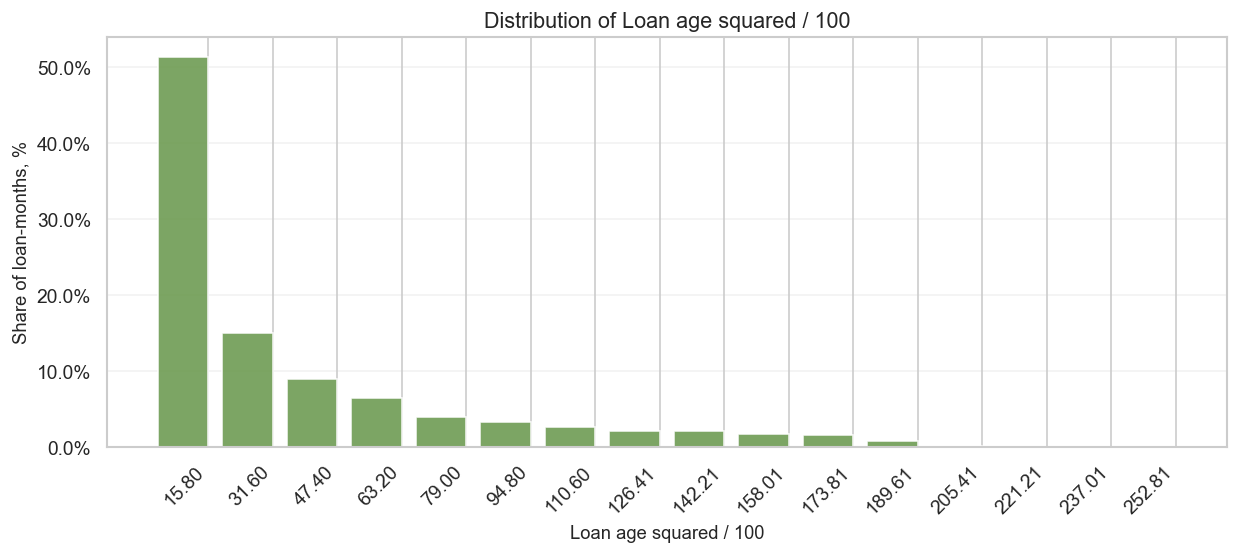

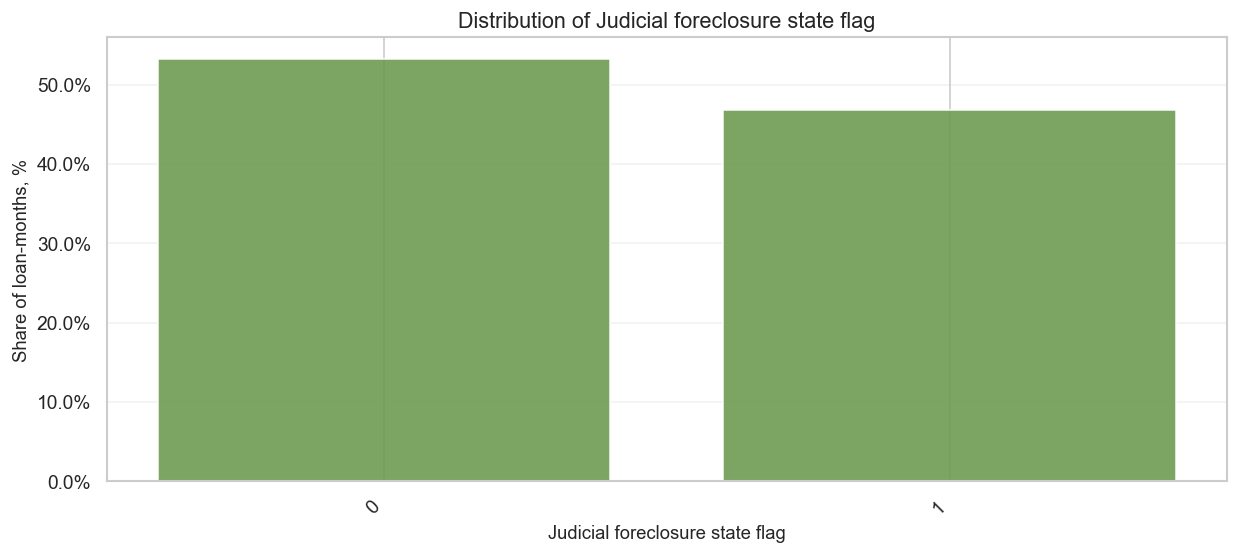

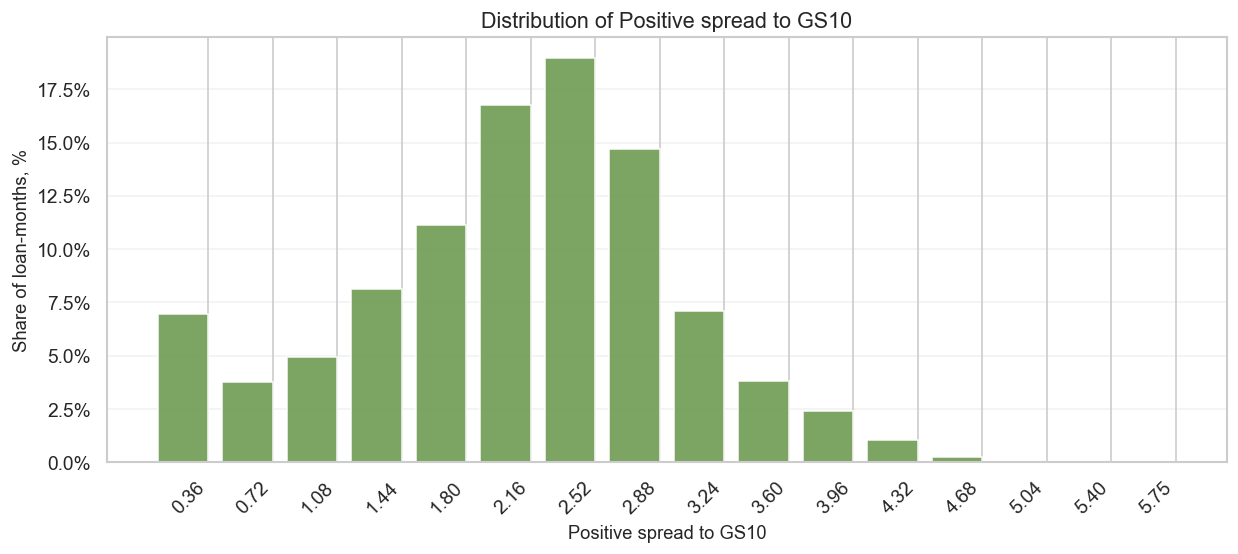

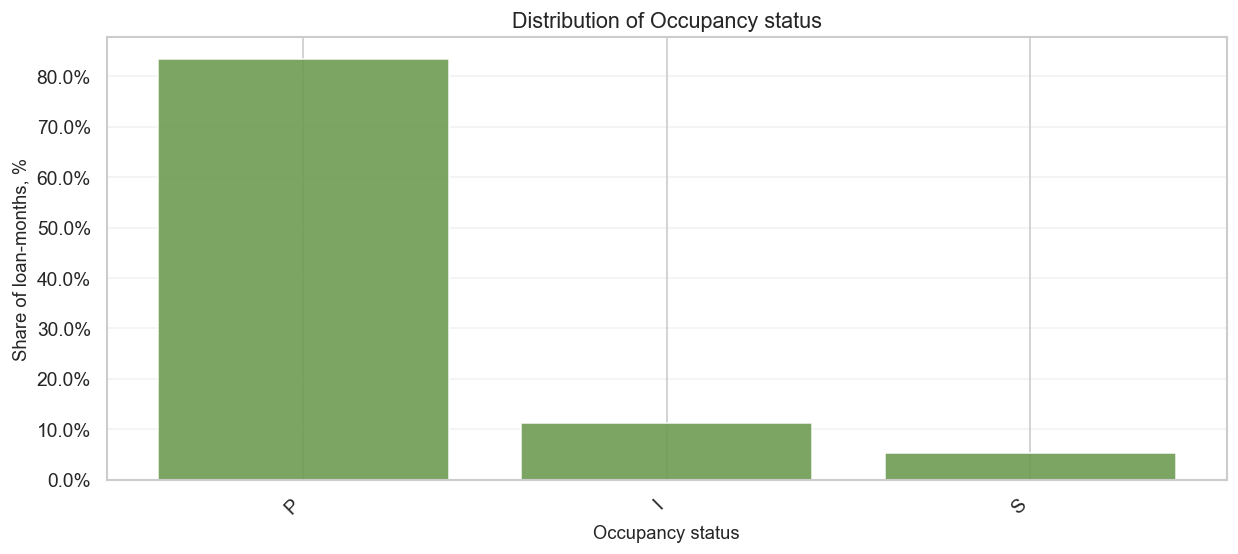

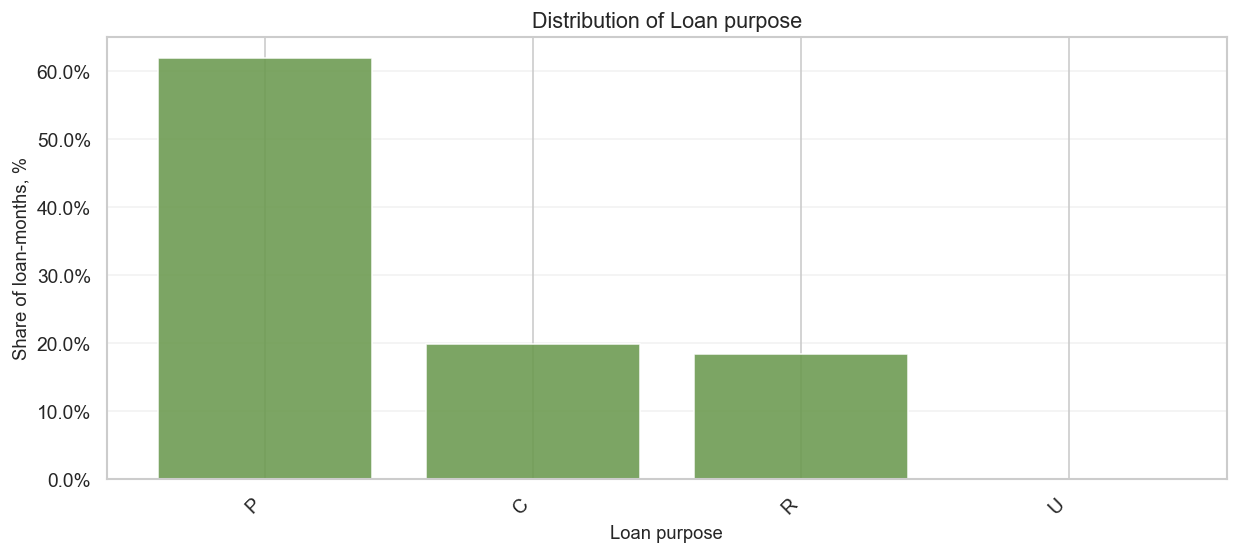

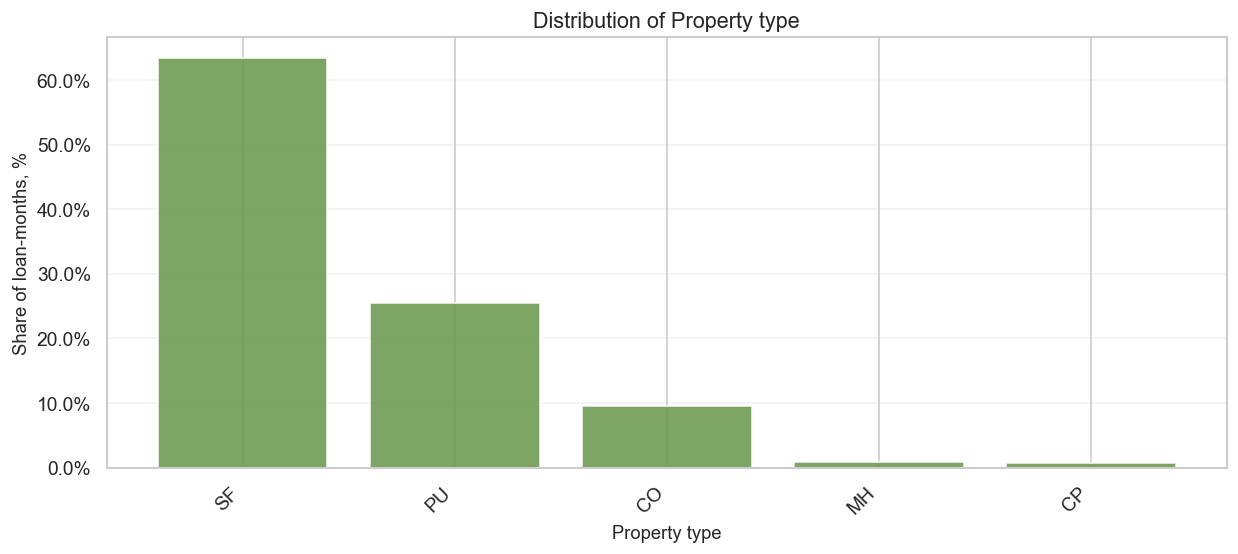

In [30]:
for feature in important_raw_features:
    plot_feature_distribution(feature)


## Prepayment intensity by month of year

In [31]:
month_labels = {
    "1": "Jan", "2": "Feb", "3": "Mar", "4": "Apr", "5": "May", "6": "Jun",
    "7": "Jul", "8": "Aug", "9": "Sep", "10": "Oct", "11": "Nov", "12": "Dec",
}

month_intensity = (
    df.filter(F.col("month_of_year").isNotNull())
    .groupBy("month_of_year")
    .agg(
        F.count("*").alias("n"),
        F.sum(TARGET_COL).alias("n_prepaid"),
        F.avg(TARGET_COL).alias("smm"),
    )
    .toPandas()
)

month_intensity["month_num"] = month_intensity["month_of_year"].astype(int)
month_intensity = month_intensity.sort_values("month_num")
month_intensity["month_label"] = month_intensity["month_of_year"].astype(str).map(month_labels)
month_intensity["smm_pct"] = month_intensity["smm"] * 100
month_intensity["cpr_pct"] = 100 * (1 - (1 - month_intensity["smm"]) ** 12)
display(month_intensity[["month_label", "n", "n_prepaid", "smm_pct", "cpr_pct"]])


,month_label,n,n_prepaid,smm_pct,cpr_pct
7,Jan,6146501,70639.0,1.149255,12.951892
11,Feb,6162846,90722.0,1.472080,16.302633
2,Mar,6145488,82941.0,1.349624,15.045787
9,Apr,6155903,85428.0,1.387741,15.438849
4,May,6165137,88655.0,1.438005,15.954627
5,Jun,6186050,82619.0,1.335570,14.900431
0,Jul,6226735,89278.0,1.433785,15.911433
3,Aug,6255643,85025.0,1.359173,15.144408
6,Sep,6289957,86174.0,1.370025,15.256370
8,Oct,6138122,79867.0,1.301163,14.543638


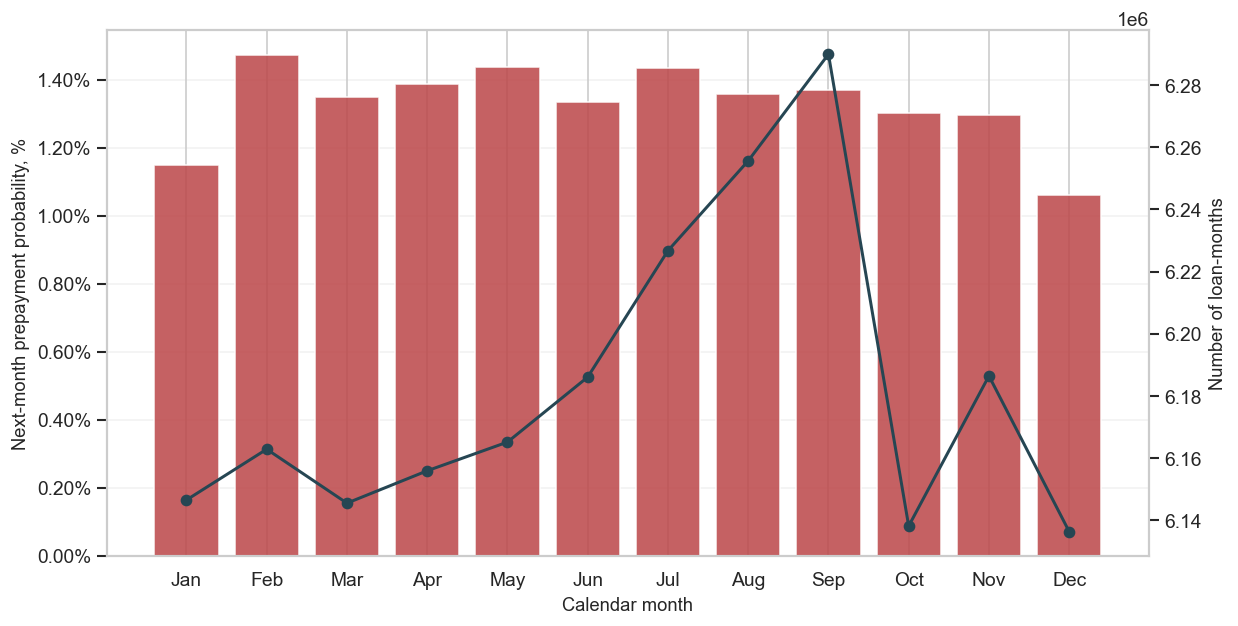

In [32]:
fig, ax = plt.subplots(figsize=(10.5, 5.4))
x_pos = np.arange(len(month_intensity))

bars = ax.bar(x_pos, month_intensity["smm_pct"], color="#bc4749", alpha=0.86)
ax.set_xticks(x_pos)
ax.set_xticklabels(month_intensity["month_label"])
ax.set_xlabel("Calendar month")
ax.set_ylabel("Next-month prepayment probability, %")
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f%%"))
ax.grid(True, axis="y", alpha=0.25)

ax2 = ax.twinx()
ax2.plot(x_pos, month_intensity["n"], color="#264653", marker="o", linewidth=1.8, label="Loan-months")
ax2.set_ylabel("Number of loan-months")
ax2.grid(False)

fig.tight_layout()
plt.show()


## Prepayment probability by FICO score

,bucket,bucket_label,n,n_prepaid,smm_pct,cpr_pct
0,4,592.17,1198,16.0,1.335559,14.900325
1,5,612.00,2323,19.0,0.817908,9.385191
2,6,631.83,651981,7788.0,1.194513,13.428939
3,7,651.67,1786040,21706.0,1.215314,13.647390
4,8,671.50,3104902,38331.0,1.234532,13.848761
5,9,691.33,4638436,60007.0,1.293690,14.465961
6,10,711.17,6154609,82119.0,1.334268,14.886963
7,11,731.00,6734368,90958.0,1.350654,15.056425
8,12,750.83,7950523,107021.0,1.346088,15.009231
9,13,770.67,10301211,141132.0,1.370053,15.256651


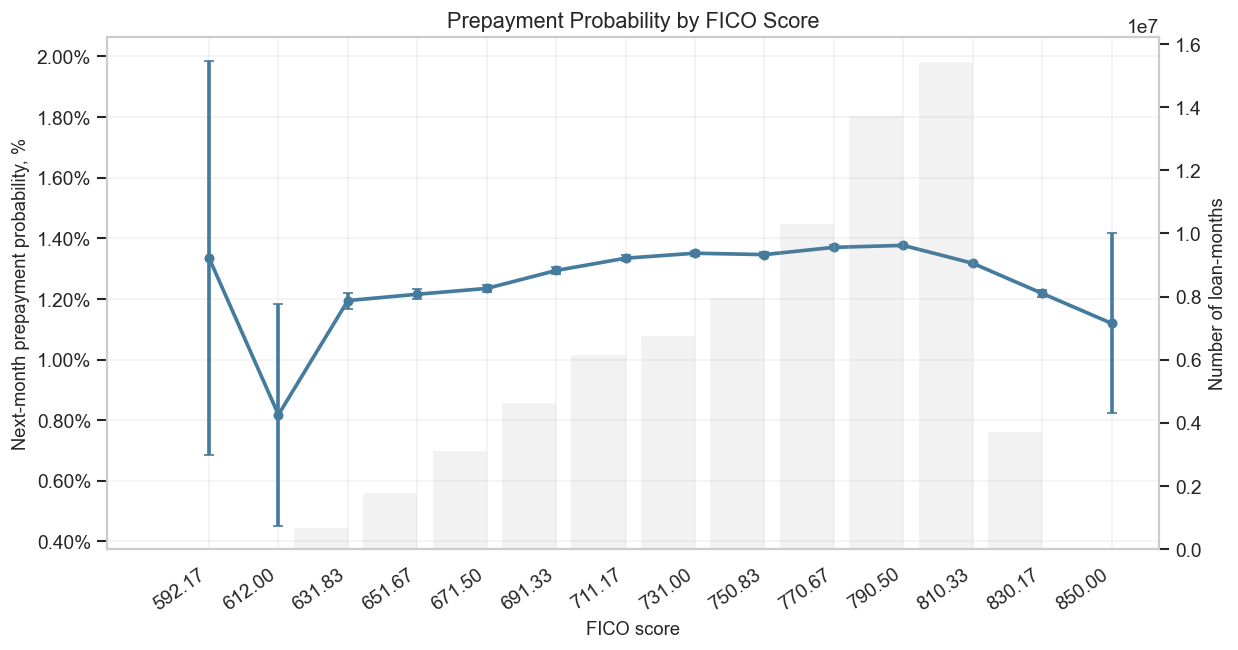

In [33]:
fico_curve, fico_cuts = aggregate_rate_curve(df, "fico", n_bins=18, min_n=1000)
display(fico_curve[["bucket", "bucket_label", "n", "n_prepaid", "smm_pct", "cpr_pct"]])

plot_rate_curve(
    fico_curve,
    x_label="FICO score",
    title="Prepayment Probability by FICO Score",
    color="#457b9d",
)


## Distributions of continuous important features

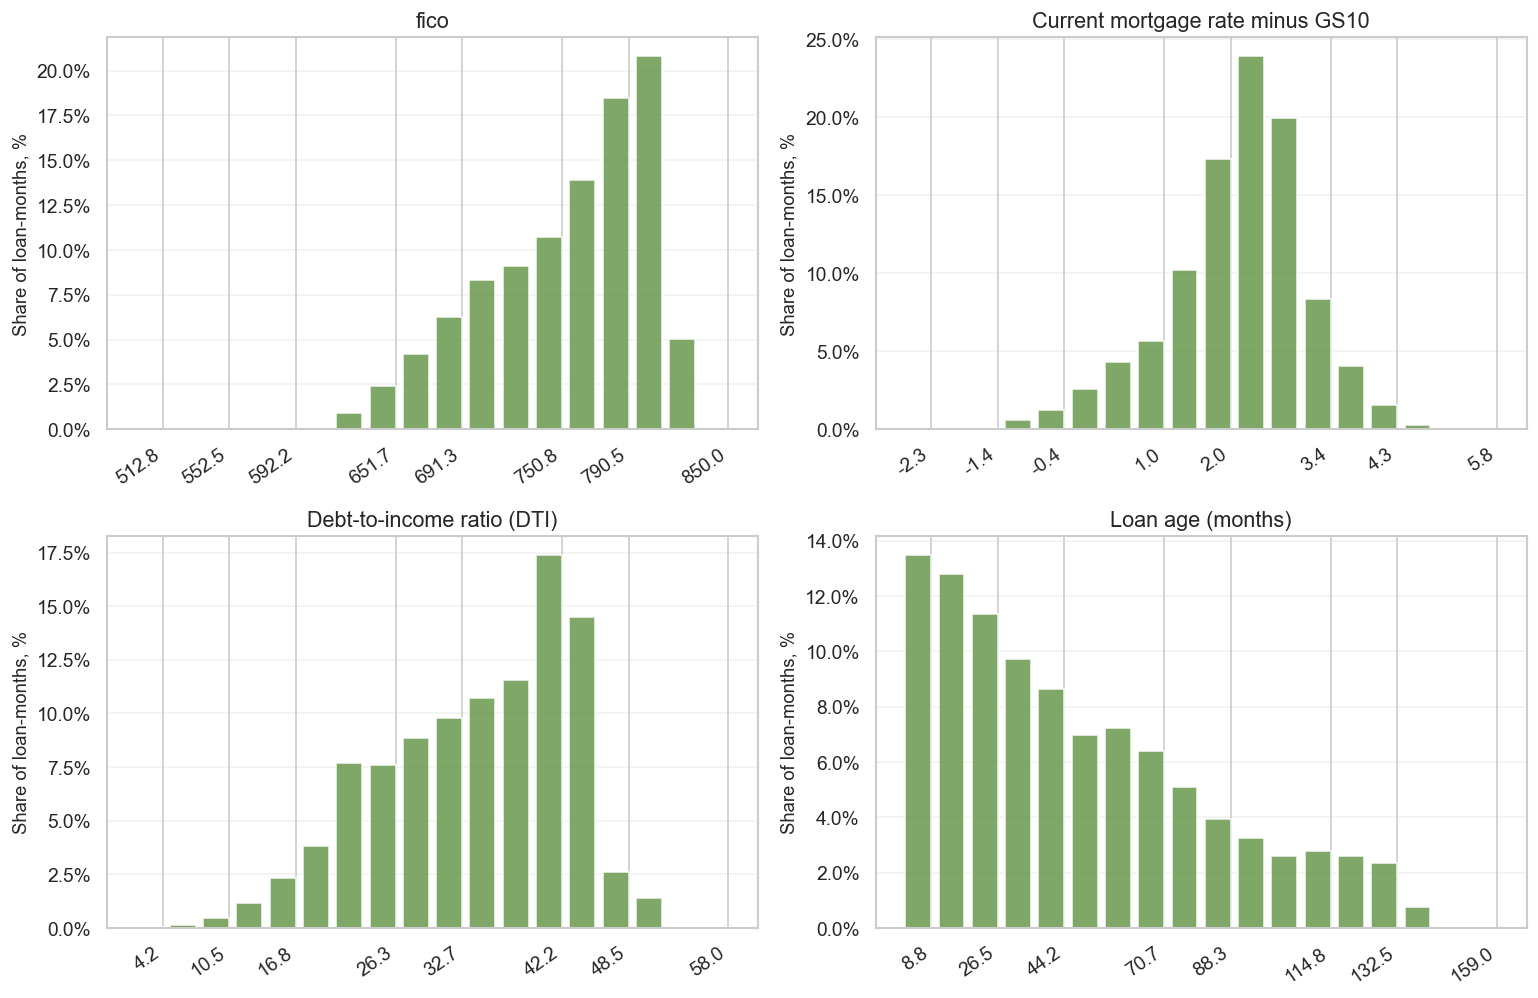

In [35]:
continuous_features_4 = [
    "fico",
    "rate_spread_to_10y",
    "dti",
    "loan_age",
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
axes = axes.flatten()

for ax, feature in zip(axes, continuous_features_4):
    dist = aggregate_feature_distribution(feature, n_bins=18)
    if dist.empty:
        ax.set_visible(False)
        continue

    dist["share_pct"] = dist["n"] / dist["n"].sum() * 100
    if "x_right" in dist.columns:
        x_pos = dist["x_right"].to_numpy()
    elif "x_max" in dist.columns:
        x_pos = dist["x_max"].to_numpy()
    else:
        x_pos = np.arange(len(dist))

    if "x_left" in dist.columns and "x_right" in dist.columns:
        widths = (dist["x_right"] - dist["x_left"]).replace(0, np.nan)
        bar_width = float(widths.median()) * 0.78
        tick_labels = [f"{x:.1f}" for x in x_pos]
    elif "x_max" in dist.columns and "x_min" in dist.columns:
        widths = (dist["x_max"] - dist["x_min"]).replace(0, np.nan)
        bar_width = float(widths.median()) * 0.78
        tick_labels = [f"{x:.2f}" for x in x_pos]
    else:
        bar_width = 0.78
        tick_labels = dist["label"].tolist()

    ax.bar(x_pos, dist["share_pct"], width=-bar_width, align="edge", color="#6a994e", alpha=0.86)
    ax.set_title(feature_label(feature))
    ax.set_ylabel("Share of loan-months, %")
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
    ax.grid(True, axis="y", alpha=0.25)

    max_ticks = min(8, len(x_pos))
    tick_idx = np.linspace(0, len(x_pos) - 1, max_ticks, dtype=int)
    ax.set_xticks(x_pos[tick_idx])
    ax.set_xticklabels([tick_labels[i] for i in tick_idx], rotation=35, ha="right")

fig.tight_layout()
plt.show()
